# S1c — Clustering de Regimes Operacionais (V2)

**Acelerado por GPU (RTX 5070) + CPU paralelo (24 cores)**

**Objetivo:** Identificar regimes operacionais distintos no circuito de moagem
usando algoritmos de clustering não-supervisionado. Esta é a versão melhorada (v2),
que incorpora seleção de features com conhecimento de domínio, pré-processamento
robusto (capping, Hampel, quasi-constantes, colinearidade) e RobustScaler.

**Melhorias v2 em relação a v1:**
- Seleção de features com conhecimento de domínio (26 → ~16 variáveis curadas)
- Capping de limites operacionais (sensores de nível ≤ 100%)
- Hampel filter para de-spiking (janela=15, k=3.0)
- Remoção de quasi-constantes (freq > 0.98)
- Remoção de colinearidade (Pearson > 0.95)
- RobustScaler (mediana/IQR) em vez de StandardScaler
- DBSCAN com sweep sistemático de eps/min_samples

**Entrada:** `dados_limpos` (banco PostgreSQL)

**Saídas:**
- `s1c_v2_metricas_clustering` — métricas de validação por algoritmo/k
- `s1c_v2_regimes` — caracterização dos regimes identificados
- `s1c_v2_regime_centroides` — centroides dos regimes por variável
- `dados_com_clusters_v2.parquet` — dados limpos + coluna regime (parquet local)
- `preprocessing_log_v2.csv` — log das etapas de preprocessing
- Figuras salvas com prefixo `S1c_v2_` (stage=s1c_v2)

**Etapas:**
1. Carga e preparação dos dados
2. Seleção de features (conhecimento de domínio)
3. Capping de limites operacionais
4. Hampel filter (de-spiking)
5. Remoção de quasi-constantes e colinearidade
6. Normalização (RobustScaler)
7. Avaliação: KMeans (GPU) + DBSCAN (sweep) + GMM para k=2..8
8. Seleção do melhor modelo (maior Silhouette)
9. Caracterização dos regimes
10. Visualizações + Comparativo v1 vs v2
11. Salvamento (parquet local + imagens no banco)

## 0 - Setup: Caminhos e Imports do Projeto

**Objetivo:** Configurar o ambiente de execução com caminhos padronizados, importar bibliotecas
do projeto (incluindo `db_utils` para persistência no banco PostgreSQL) e definir constantes
do pipeline de clustering.

**Parâmetros:**
- `STAGE = "s1c_v2"`: identificador da sprint/versão para nomeação de tabelas e figuras no banco
- `K_RANGE = range(2, 9)`: faixa de k testada (2 a 8 clusters) — cobre desde a separação mínima até granularidade razoável sem overfitting
- `DEVICE = cuda/cpu`: usa GPU (RTX 5070) se disponível para acelerar KMeans e PCA via PyTorch

**Justificativa:** O bloco de setup centraliza todos os caminhos e imports, garantindo que o
notebook funcione independente do diretório de execução. A conexão com o banco via `db_utils`
permite persistir resultados para consumo pelo dashboard e rastreabilidade entre versões.

In [26]:
# ==============================================================================
# Setup: caminhos e imports do projeto
# ==============================================================================
import sys, os, time
from pathlib import Path

# Raiz do projeto — resolve independente de onde o notebook é executado
PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")

# Caminhos padronizados
DATA_RAW     = PROJECT_ROOT / "data" / "raw"
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_LABEL   = PROJECT_ROOT / "data" / "labeled"
FIGURES_DIR  = PROJECT_ROOT / "figures" / "01_sprint1" / "clustering_v2"
MODELS_DIR   = PROJECT_ROOT / "models"
REPORTS_DIR  = PROJECT_ROOT / "reports"

# Adicionar diretório de scripts ao path (para importar db_utils, etc.)
SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

# Garantir que os diretórios de saída existem
for d in [DATA_PROC, DATA_LABEL, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ==============================================================================
# Imports de bibliotecas
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from joblib import Parallel, delayed

# ── Importar módulos do projeto (db_utils) ──
from db_utils import carregar_dados, salvar_dataframe, salvar_imagem

# ── GPU check ──
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_CPU  = max(1, os.cpu_count() - 2)

# ── rcParams padrão do projeto ──
sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 19,
    "figure.titlesize": 21,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

STAGE = "s1c"
K_RANGE = range(2, 9)
VERSAO = "v2"
t0 = time.time()

print("=" * 60)
print(f"  Sprint 1c — Clustering de Regimes Operacionais (v2)")
print("=" * 60)
print(f"  GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A (CPU mode)'}")
print(f"  CPUs: {N_CPU}")
print(f"  Saida: {FIGURES_DIR}")

  Sprint 1c — Clustering de Regimes Operacionais (v2)
  GPU: NVIDIA GeForce RTX 5070 Laptop GPU
  CPUs: 22
  Saida: C:\ScriptsDatamindsPIP\4-Projeto aplicado\figures\01_sprint1\clustering_v2


## 1 - Carga dos Dados

**Objetivo:** Carregar o dataset limpo (`dados_limpos`) do banco PostgreSQL via `carregar_dados()`
e preparar as colunas de processo para o pipeline de clustering.

**Parâmetros:**
- Tabela de entrada: `dados_limpos` (saída do notebook S1a — Preparação de Dados)
- `col_tph`: coluna da balança de alimentação, identificada automaticamente para caracterização dos regimes
- `nome_curto()`: função auxiliar que remove sufixos de tag PI e prefixos numéricos para visualizações legíveis

**Justificativa:** Os dados já passaram por limpeza (remoção de duplicatas, tratamento de outliers IQR,
imputação de NaN) no notebook S1a. A função `carregar_dados()` do `db_utils` garante que os dados
venham diretamente do banco PostgreSQL, mantendo consistência com o pipeline principal.

**Saída esperada:** DataFrame com ~632k registros x 26 variáveis de processo, indexado por Timestamp.

In [27]:
# Carregar dados limpos do banco PostgreSQL (saída do notebook S1a — Preparação de Dados)
# Os dados já passaram por limpeza, tratamento de outliers e remoção de duplicatas
df = carregar_dados("dados_limpos")
df = df.drop(columns=["id"], errors="ignore")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()

# Todas as colunas de processo (antes da seleção)
COLS_TODAS = [c for c in df.columns if c != "Timestamp"]

# Log de preprocessing (rastreia cada etapa de transformação)
preprocessing_log = []

# Função auxiliar para nomes curtos nas visualizações
import re
def nome_curto(col):
    """Remove sufixo _pipoint e prefixo numérico, mantendo nome único."""
    nome = col.replace("_pipoint", "").strip()
    nome = re.sub(r'^\d{4}_', '', nome)
    nome = re.sub(r'\s*_\s*', ' ', nome).strip()
    return nome

# Identificar coluna de TPH (balança de alimentação) para caracterização dos regimes
_cols_tph = [c for c in COLS_TODAS if "BALANÇA" in c.upper()]
if not _cols_tph:
    raise ValueError("Nenhuma coluna com 'BALANÇA' encontrada. Verifique os dados de entrada.")
col_tph = _cols_tph[0]

print(f"Dataset carregado: {df.shape[0]:,} registros x {df.shape[1]} variaveis")
print(f"Periodo: {df.index.min()} a {df.index.max()}")
print(f"\nColunas disponiveis ({len(COLS_TODAS)}):")
for i, c in enumerate(COLS_TODAS, 1):
    print(f"  {i:2d}. {nome_curto(c):40s} ← {c}")

[db_utils] 632985 linhas carregadas de otimizar_moagem_aura.dados_limpos
Dataset carregado: 632,985 registros x 27 variaveis
Periodo: 2024-08-01 00:00:00 a 2026-03-01 00:00:00

Colunas disponiveis (27):
   1. BRITAGEM SL01 NÍVEL                      ← 1010_BRITAGEM _ SL01 _ NÍVEL_pipoint
   2. RETOMADA SL01 NIVEL                      ← 1025_RETOMADA_SL01_NIVEL_pipoint
   3. RETOMADA AL01 SETPOINT                   ← 1025_RETOMADA _ AL01 _ SETPOINT_pipoint
   4. RETOMADA AL02 SETPOINT                   ← 1025_RETOMADA _ AL02 _ SETPOINT_pipoint
   5. RETOMADA AL03 SETPOINT                   ← 1025_RETOMADA _ AL03 _ SETPOINT_pipoint
   6. RETOMADA TR02 BALANÇA                    ← 1025_RETOMADA _ TR02 _ BALANÇA_pipoint
   7. RETOMADA TR02 CORRENTE                   ← 1025_RETOMADA _ TR02 _ CORRENTE_pipoint
   8. MOAGEM CX01 NÍVEL                        ← 1030_MOAGEM _ CX01 _ NÍVEL_pipoint
   9. MOAGEM HCALIMENTAÇÃO DENSIDADE           ← 1030_MOAGEM _ HCALIMENTAÇÃO _ DENSIDADE_pipoint
  10

## 1.5 - Seleção de Features (Conhecimento de Domínio)

**Objetivo:** Selecionar as variáveis mais relevantes para clustering com base em conhecimento do processo industrial.

**Variáveis descartadas e justificativa:**
- `BRITAGEM_SL01_NÍVEL`: área upstream
- `RETOMADA_SL01_NIVEL`: >50% valores ausentes
- `RETOMADA_AL01/02/03_SETPOINT`: setpoints fixos
- `MOAGEM_HCALIMENTAÇÃO_VAZÃO`: falha no sensor
- `MOAGEM_HCALIMENTAÇÃO_DENSIDADE`: não discriminante
- `MOAGEM_MO01ÁGUADESCARGAMOINHO_VAZÃO`: erros de instrumento
- `MOAGEM_MO01_VAZAO`: erros de instrumento
- `MOAGEM_MO01MANCALENTRADA_PRESSÃO`: redundante com mancal saída
- `MOAGEM_TR01_TRANSMISSORDEPESO`: alta variabilidade + gaps

**Resultado:** 16 variáveis selecionadas para clustering.

In [28]:
# ==============================================================================
# 1.5 Seleção de features — conhecimento de domínio
# ==============================================================================
DESCARTAR_PATTERNS = [
    "BRITAGEM",                     # Área upstream
    "RETOMADA_SL01",                # >50% NaN
    "AL01 _ SETPOINT",              # Setpoints fixos
    "AL02 _ SETPOINT",
    "AL03 _ SETPOINT",
    "HCALIMENTAÇÃO _ VAZÃO",        # Falha sensor
    "HCALIMENTAÇÃO _ DENSIDADE",    # Não discriminante
    "MO01ÁGUADESCARGAMOINHO",       # Erros instrumento
    "MO01_VAZAO",                   # Erros instrumento
    "MO01MANCALENTRADA",            # Redundante com mancal saída
    "TR01 _ TRANSMISSORDEPESO",     # Variabilidade + gaps
]

def deve_descartar(col):
    col_upper = col.upper()
    for pat in DESCARTAR_PATTERNS:
        if pat.upper() in col_upper:
            return True
    return False

cols_antes = len(COLS_TODAS)
COLS_EXPERT = [c for c in COLS_TODAS if not deve_descartar(c)]
cols_descartadas = [c for c in COLS_TODAS if deve_descartar(c)]

preprocessing_log.append({
    "versao": VERSAO, "etapa": "1_selecao_features",
    "descricao": "Selecao de features com conhecimento de dominio",
    "colunas_antes": cols_antes, "colunas_depois": len(COLS_EXPERT),
    "registros_antes": len(df), "registros_depois": len(df),
    "colunas_removidas": "; ".join(cols_descartadas),
    "parametros": f"{len(DESCARTAR_PATTERNS)} padroes de exclusao"
})

print(f"Features: {cols_antes} \u2192 {len(COLS_EXPERT)} (descartadas: {len(cols_descartadas)})")
print(f"\nDescartadas:")
for c in cols_descartadas:
    print(f"  \u2717 {c}")
print(f"\nSelecionadas ({len(COLS_EXPERT)}):")
for c in COLS_EXPERT:
    print(f"  \u2713 {c}")

Features: 27 → 16 (descartadas: 11)

Descartadas:
  ✗ 1010_BRITAGEM _ SL01 _ NÍVEL_pipoint
  ✗ 1025_RETOMADA_SL01_NIVEL_pipoint
  ✗ 1025_RETOMADA _ AL01 _ SETPOINT_pipoint
  ✗ 1025_RETOMADA _ AL02 _ SETPOINT_pipoint
  ✗ 1025_RETOMADA _ AL03 _ SETPOINT_pipoint
  ✗ 1030_MOAGEM _ HCALIMENTAÇÃO _ DENSIDADE_pipoint
  ✗ 1030_MOAGEM _ HCALIMENTAÇÃO _ VAZÃO_pipoint
  ✗ 1030_MOAGEM _ MO01MANCALENTRADA _ PRESSÃO_pipoint
  ✗ 1030_MOAGEM _ MO01ÁGUADESCARGAMOINHO _ VAZÃO_pipoint
  ✗ 1030_MOAGEM _ MO01_VAZAO_pipoint
  ✗ 1030_MOAGEM _ TR01 _ TRANSMISSORDEPESO_pipoint

Selecionadas (16):
  ✓ 1025_RETOMADA _ TR02 _ BALANÇA_pipoint
  ✓ 1025_RETOMADA _ TR02 _ CORRENTE_pipoint
  ✓ 1030_MOAGEM _ CX01 _ NÍVEL_pipoint
  ✓ 1030_MOAGEM _ HC _ PRESSÃO_pipoint
  ✓ 1030_MOAGEM _ MO01MANCALSAÍDA _ PRESSÃO_pipoint
  ✓ 1030_MOAGEM _ MO01 _ CORRENTE_pipoint
  ✓ 1030_MOAGEM _ MO01 _ OUVIDOELETRÔNICO_pipoint
  ✓ 1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint
  ✓ 1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint
  ✓ 1030_MOAGEM _ MO01 _ TORQ

## 1.6 - Capping de Limites Operacionais

**Objetivo:** Limitar valores de sensores de nível a 100%, pois valores acima são artefatos de instrumento (sensor saturado).

**Parâmetros:**
- Colunas afetadas: todas contendo "NÍVEL" no nome
- Limite máximo: 100.0

**Justificativa:** Sensores de nível com leituras >100% representam saturação do instrumento, não condições operacionais reais. Esses valores distorcem a normalização e os centroides do clustering.

In [29]:
# ==============================================================================
# 1.6 Capping de limites operacionais — sensores de nível ≤ 100%
# ==============================================================================
LIMITE_NIVEL = 100.0
cols_nivel = [c for c in COLS_EXPERT if "NÍVEL" in c.upper() or "NIVEL" in c.upper()]
total_capped = 0

for col in cols_nivel:
    mask = df[col] > LIMITE_NIVEL
    n_capped = mask.sum()
    if n_capped > 0:
        df.loc[mask, col] = LIMITE_NIVEL
        total_capped += n_capped
        print(f"  {col}: {n_capped:,} valores capped")

preprocessing_log.append({
    "versao": VERSAO, "etapa": "2_capping_limites",
    "descricao": f"Capping sensores de nivel <= {LIMITE_NIVEL}%",
    "colunas_antes": len(COLS_EXPERT), "colunas_depois": len(COLS_EXPERT),
    "registros_antes": len(df), "registros_depois": len(df),
    "colunas_removidas": "",
    "parametros": f"cols_nivel={cols_nivel}, limite={LIMITE_NIVEL}, total_capped={total_capped}"
})

print(f"\nCapping: {len(cols_nivel)} colunas de nivel, {total_capped:,} valores ajustados")

  1030_MOAGEM _ CX01 _ NÍVEL_pipoint: 6,351 valores capped
  2020_SISTEMADEÁGUA _ TQ01 _ NÍVEL_pipoint: 7,057 valores capped

Capping: 4 colunas de nivel, 13,408 valores ajustados


## 1.7 - Hampel Filter (De-spiking)

**Objetivo:** Remover spikes pontuais (artefatos de medição) usando filtro de mediana local com detecção via MAD (Median Absolute Deviation).

**Parâmetros:**
- `janela = 15`: janela móvel (15 minutos com dados 1min)
- `k = 3.0`: limiar de robustez (3σ do MAD)
- Constante 1.4826: fator de normalização para distribuição normal

**Justificativa:** Spikes curtos (1-3 minutos) representam artefatos de instrumento que o tratamento IQR do S1a pode não capturar. O Hampel filter preserva a tendência local enquanto remove apenas picos anômalos.

In [30]:
# ==============================================================================
# 1.7 Hampel Filter — implementação vetorizada (rápida para 632k rows)
# ==============================================================================
HAMPEL_JANELA = 15
HAMPEL_K = 3.0
HAMPEL_SCALE = 1.4826  # Fator de normalização MAD → σ

total_spikes = 0
t_hampel = time.time()

for col in COLS_EXPERT:
    series = df[col]
    # Mediana local (janela centrada)
    median_local = series.rolling(window=HAMPEL_JANELA, center=True, min_periods=1).median()
    # MAD local (Median Absolute Deviation)
    desvio = (series - median_local).abs()
    mad_local = desvio.rolling(window=HAMPEL_JANELA, center=True, min_periods=1).median()
    # Limiar: k * 1.4826 * MAD
    threshold = HAMPEL_K * HAMPEL_SCALE * mad_local
    # Detectar spikes
    mask_spike = desvio > threshold
    n_spikes = mask_spike.sum()
    if n_spikes > 0:
        df.loc[mask_spike, col] = median_local[mask_spike]
        total_spikes += n_spikes
        pct = 100 * n_spikes / len(series)
        if pct > 0.01:
            print(f"  {col}: {n_spikes:>8,} spikes ({pct:.2f}%)")

dt_hampel = time.time() - t_hampel

preprocessing_log.append({
    "versao": VERSAO, "etapa": "3_hampel_filter",
    "descricao": f"Hampel de-spiking (janela={HAMPEL_JANELA}, k={HAMPEL_K})",
    "colunas_antes": len(COLS_EXPERT), "colunas_depois": len(COLS_EXPERT),
    "registros_antes": len(df), "registros_depois": len(df),
    "colunas_removidas": "",
    "parametros": f"janela={HAMPEL_JANELA}, k={HAMPEL_K}, total_spikes={total_spikes}"
})

print(f"\nHampel: {total_spikes:,} spikes removidos em {len(COLS_EXPERT)} colunas ({dt_hampel:.1f}s)")

  1025_RETOMADA _ TR02 _ BALANÇA_pipoint:   27,248 spikes (4.30%)
  1025_RETOMADA _ TR02 _ CORRENTE_pipoint:   28,254 spikes (4.46%)
  1030_MOAGEM _ CX01 _ NÍVEL_pipoint:   48,834 spikes (7.71%)
  1030_MOAGEM _ HC _ PRESSÃO_pipoint:   28,233 spikes (4.46%)
  1030_MOAGEM _ MO01MANCALSAÍDA _ PRESSÃO_pipoint:   16,304 spikes (2.58%)
  1030_MOAGEM _ MO01 _ CORRENTE_pipoint:   22,624 spikes (3.57%)
  1030_MOAGEM _ MO01 _ OUVIDOELETRÔNICO_pipoint:   50,457 spikes (7.97%)
  1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint:   25,707 spikes (4.06%)
  1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint:   51,672 spikes (8.16%)
  1030_MOAGEM _ MO01 _ TORQUE_pipoint:   19,545 spikes (3.09%)
  1035_ESPESSAMENTO _ EP01ALIMENTAÇÃOCIL _ VAZÃO_pipoint:   29,127 spikes (4.60%)
  1035_ESPESSAMENTO _ EP01 _ PH_pipoint:   26,566 spikes (4.20%)
  1035_ESPESSAMENTO _ EP01 _ PRESSÃOSAÍDA_pipoint:   43,332 spikes (6.85%)
  1065_DETOX _ CX01 _ NÍVEL_pipoint:   17,268 spikes (2.73%)
  2020_SISTEMADEÁGUA _ TQ01 _ NÍVEL_pipoint:   90,876 s

## 1.8 - Remoção de Quasi-Constantes

**Objetivo:** Remover variáveis com variação insuficiente.

**Parâmetros:**
- `limiar_freq = 0.98`: descarta se o valor mais frequente aparece em ≥98% dos registros
- `limiar_std = 1e-8`: descarta se desvio padrão ≤ 1e-8

In [31]:
# ==============================================================================
# 1.8 Remoção de quasi-constantes
# ==============================================================================
LIMIAR_FREQ = 0.98
LIMIAR_STD = 1e-8

cols_antes_qc = len(COLS_EXPERT)
cols_quase_const = []

for col in COLS_EXPERT:
    s = df[col].dropna()
    if len(s) == 0:
        cols_quase_const.append(col)
        continue
    freq_top = s.value_counts(normalize=True).iloc[0]
    std_val = s.std()
    if freq_top >= LIMIAR_FREQ or std_val <= LIMIAR_STD:
        cols_quase_const.append(col)
        print(f"  \u2717 {col}  freq_top={freq_top:.4f}  std={std_val:.6f}")

COLS_EXPERT = [c for c in COLS_EXPERT if c not in cols_quase_const]

preprocessing_log.append({
    "versao": VERSAO, "etapa": "4_quasi_constantes",
    "descricao": f"Remocao quasi-constantes (freq>={LIMIAR_FREQ} ou std<={LIMIAR_STD})",
    "colunas_antes": cols_antes_qc, "colunas_depois": len(COLS_EXPERT),
    "registros_antes": len(df), "registros_depois": len(df),
    "colunas_removidas": "; ".join(cols_quase_const),
    "parametros": f"limiar_freq={LIMIAR_FREQ}, limiar_std={LIMIAR_STD}"
})

if cols_quase_const:
    print(f"\nQuasi-constantes removidas: {len(cols_quase_const)}")
else:
    print("Nenhuma variavel quasi-constante encontrada")

Nenhuma variavel quasi-constante encontrada


## 1.9 - Remoção de Colinearidade

**Objetivo:** Remover variáveis altamente correlacionadas (|r| ≥ 0.95) que inflam artificialmente a importância de certas dimensões no clustering.

**Parâmetros:**
- `limiar_correlacao = 0.95`: correlação de Pearson absoluta
- Critério de remoção: entre o par correlacionado, remove a variável com maior correlação média absoluta com todas as demais

**Justificativa:** Variáveis colineares representam informação redundante. No clustering baseado em distância (KMeans, DBSCAN), elas efetivamente "duplicam" a contribuição de uma mesma dimensão, enviesando os centroides.

In [32]:
# ==============================================================================
# 1.9 Remoção de colinearidade — Pearson ≥ 0.95
# ==============================================================================
LIMIAR_CORR = 0.95

cols_antes_corr = len(COLS_EXPERT)
corr_matrix = df[COLS_EXPERT].corr(method="pearson").abs()
# Copiar valores para array editável antes de zerar a diagonal
corr_vals = corr_matrix.values.copy()
np.fill_diagonal(corr_vals, 0)
df_corr = pd.DataFrame(corr_vals, index=corr_matrix.index, columns=corr_matrix.columns)

# Correlação média absoluta de cada variável com todas as demais
mean_corr = df_corr.mean(axis=0)

# Encontrar pares com correlação >= limiar
cols_remover_corr = set()
pares_log = []
for i in range(len(COLS_EXPERT)):
    for j in range(i + 1, len(COLS_EXPERT)):
        if df_corr.iloc[i, j] >= LIMIAR_CORR:
            c1, c2 = COLS_EXPERT[i], COLS_EXPERT[j]
            if mean_corr[c1] >= mean_corr[c2]:
                cols_remover_corr.add(c1)
                removida, mantida = c1, c2
            else:
                cols_remover_corr.add(c2)
                removida, mantida = c2, c1
            pares_log.append(f"{c1} x {c2} = {df_corr.iloc[i,j]:.4f} \u2192 remove {removida}")
            print(f"  {c1} x {c2} = {df_corr.iloc[i,j]:.4f}  \u2192 remove {removida}")

COLS_CLUSTER = [c for c in COLS_EXPERT if c not in cols_remover_corr]

preprocessing_log.append({
    "versao": VERSAO, "etapa": "5_colinearidade",
    "descricao": f"Remocao colinearidade (Pearson >= {LIMIAR_CORR})",
    "colunas_antes": cols_antes_corr, "colunas_depois": len(COLS_CLUSTER),
    "registros_antes": len(df), "registros_depois": len(df),
    "colunas_removidas": "; ".join(list(cols_remover_corr)),
    "parametros": f"limiar={LIMIAR_CORR}, pares={len(pares_log)}"
})

print(f"\nColinearidade: {cols_antes_corr} \u2192 {len(COLS_CLUSTER)} features (removidas: {len(cols_remover_corr)})")
print(f"\nFeatures finais para clustering ({len(COLS_CLUSTER)}):")
for c in COLS_CLUSTER:
    print(f"  \u2713 {c}")

NOMES_CURTOS = {c: nome_curto(c) for c in COLS_CLUSTER}


Colinearidade: 16 → 16 features (removidas: 0)

Features finais para clustering (16):
  ✓ 1025_RETOMADA _ TR02 _ BALANÇA_pipoint
  ✓ 1025_RETOMADA _ TR02 _ CORRENTE_pipoint
  ✓ 1030_MOAGEM _ CX01 _ NÍVEL_pipoint
  ✓ 1030_MOAGEM _ HC _ PRESSÃO_pipoint
  ✓ 1030_MOAGEM _ MO01MANCALSAÍDA _ PRESSÃO_pipoint
  ✓ 1030_MOAGEM _ MO01 _ CORRENTE_pipoint
  ✓ 1030_MOAGEM _ MO01 _ OUVIDOELETRÔNICO_pipoint
  ✓ 1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint
  ✓ 1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint
  ✓ 1030_MOAGEM _ MO01 _ TORQUE_pipoint
  ✓ 1035_ESPESSAMENTO _ EP01ALIMENTAÇÃOCIL _ VAZÃO_pipoint
  ✓ 1035_ESPESSAMENTO _ EP01 _ PH_pipoint
  ✓ 1035_ESPESSAMENTO _ EP01 _ PRESSÃOSAÍDA_pipoint
  ✓ 1065_DETOX _ CX01 _ NÍVEL_pipoint
  ✓ 2020_SISTEMADEÁGUA _ TQ01 _ NÍVEL_pipoint
  ✓ 2020_SISTEMADEÁGUA _ TQ02 _ NÍVEL_pipoint


## 2 - Preparação e Normalização

**Objetivo:** Tratar valores ausentes e normalizar os dados com RobustScaler.

**Parâmetros:**
- Limiar de exclusão: `>50% NaN`
- `RobustScaler`: normalização baseada em mediana e IQR (Q1-Q3)

**Justificativa (mudança v1→v2):** O StandardScaler (v1) usa média/desvio, sensível a outliers. 
O RobustScaler usa mediana/IQR, preservando a escala natural dos dados industriais.

In [33]:
# Verificar colunas com excesso de valores ausentes (>50%)
# Colunas com mais da metade dos valores faltantes não contribuem para o clustering
nan_pct = df[COLS_CLUSTER].isnull().mean()
cols_excluir = nan_pct[nan_pct > 0.5].index.tolist()
if cols_excluir:
    print(f"\nColunas excluidas (>50% NaN): {cols_excluir}")
    COLS_CLUSTER = [c for c in COLS_CLUSTER if c not in cols_excluir]

# Remover linhas com NaN restantes — clustering requer matriz completa
df_clean = df[COLS_CLUSTER].dropna()
print(f"Registros para clustering: {len(df_clean):,} ({100*len(df_clean)/len(df):.1f}%)")
print(f"Features para clustering: {len(COLS_CLUSTER)}")

# Normalização RobustScaler (mediana=0, IQR=1)
# Mais robusto a outliers que o StandardScaler usado na v1
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_clean)

preprocessing_log.append({
    "versao": VERSAO, "etapa": "6_normalizacao",
    "descricao": "RobustScaler (mediana/IQR)",
    "colunas_antes": len(COLS_CLUSTER), "colunas_depois": len(COLS_CLUSTER),
    "registros_antes": len(df), "registros_depois": len(df_clean),
    "colunas_removidas": "; ".join(cols_excluir) if cols_excluir else "",
    "parametros": "RobustScaler(quantile_range=(25,75))"
})

# Transferir para GPU (tensor PyTorch float32)
# A GPU permite cálculo vetorizado de distâncias com torch.cdist
X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=DEVICE)
print(f"Dados na GPU: {X_tensor.shape} ({X_tensor.element_size() * X_tensor.nelement() / 1e6:.0f} MB)")

Registros para clustering: 632,985 (100.0%)
Features para clustering: 16
Dados na GPU: torch.Size([632985, 16]) (41 MB)


## 2.1 - Implementação KMeans na GPU (PyTorch)

**Objetivo:** Implementar KMeans usando operações tensoriais do PyTorch para execução na GPU, evitando transferências CPU↔GPU.

**Parâmetros:**
- `max_iter = 300`: limite de iterações por inicialização — padrão do sklearn
- `n_init = 10`: número de inicializações aleatórias — seleciona a de menor inércia
- Convergência: `shift < 1e-6` — para quando centroides param de se mover

**Justificativa:** O sklearn KMeans não suporta GPU. A implementação via PyTorch usa `torch.cdist` para cálculo vetorizado de distâncias, aproveitando a RTX 5070 para ~800k registros.

In [34]:
# GPU KMeans — implementacao PyTorch
def kmeans_gpu(X: torch.Tensor, k: int, max_iter: int = 300, n_init: int = 10, seed: int = 42):
    """KMeans completo na GPU via PyTorch. Retorna labels e inertia."""
    n, d = X.shape
    best_labels = None
    best_inertia = float("inf")

    for init_i in range(n_init):
        rng = torch.Generator(device=X.device).manual_seed(seed + init_i)
        idx = torch.randperm(n, generator=rng, device=X.device)[:k]
        centers = X[idx].clone()

        for _ in range(max_iter):
            # Distancias ao quadrado (broadcasting eficiente)
            dists = torch.cdist(X, centers, p=2.0)
            labels = dists.argmin(dim=1)

            # Atualizar centroides
            new_centers = torch.zeros_like(centers)
            counts = torch.zeros(k, device=X.device)
            for j in range(k):
                mask = labels == j
                if mask.any():
                    new_centers[j] = X[mask].mean(dim=0)
                    counts[j] = mask.sum()
                else:
                    new_centers[j] = X[torch.randint(n, (1,), device=X.device)]

            # Convergencia
            shift = (new_centers - centers).norm()
            centers = new_centers
            if shift < 1e-6:
                break

        # Inertia
        dists_final = torch.cdist(X, centers, p=2.0)
        min_dists = dists_final.min(dim=1).values
        inertia = (min_dists ** 2).sum().item()

        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.cpu().numpy()
            best_centers = centers.cpu().numpy()

    return best_labels, best_inertia, best_centers

## 2.2 - Implementação PCA na GPU (PyTorch SVD)

**Objetivo:** Reduzir dimensionalidade via PCA usando decomposição SVD na GPU para visualização 2D dos clusters.

**Parâmetros:**
- `n_components = 2`: projeção em 2 dimensões para scatter plot

**Justificativa:** PCA via SVD na GPU é mais rápido que o sklearn para datasets grandes. A variância explicada por PC1+PC2 indica a qualidade da representação 2D.

In [35]:
# PCA via decomposição SVD na GPU
def pca_gpu(X: torch.Tensor, n_components: int = 2):
    """Redução de dimensionalidade via SVD na GPU.
    Retorna: projeções (numpy), variância explicada por componente (numpy)."""
    X_centered = X - X.mean(dim=0)        # Centralizar dados (média zero)
    U, S, Vt = torch.linalg.svd(X_centered, full_matrices=False)
    components = Vt[:n_components]          # Componentes principais
    X_proj = X_centered @ components.T      # Projetar dados
    var_total = (S ** 2).sum()
    var_explained = (S[:n_components] ** 2) / var_total  # Proporção da variância
    return X_proj.cpu().numpy(), var_explained.cpu().numpy()

## 3 - Avaliação de Algoritmos de Clustering

**Objetivo:** Executar KMeans (GPU), DBSCAN (sweep sistemático) e GMM para k=2..8.

**Parâmetros:**
- KMeans: `n_init=10`, GPU via PyTorch
- DBSCAN (v2): sweep de eps (50-100% do centro, steps 5%) × min_samples (6,8,10,12)
- GMM: `covariance_type="full"`, `n_init=3`
- Métricas: Silhouette, Davies-Bouldin, Calinski-Harabasz

In [36]:
# ============================================================
# 3a. KMeans na GPU — varrer k de 2 a 8
# ============================================================
print("\n--- Avaliando KMeans (GPU) ---")
resultados = []

for k in K_RANGE:
    t1 = time.time()
    labels, inertia, centers = kmeans_gpu(X_tensor, k)

    sil = silhouette_score(X_scaled, labels, sample_size=min(50000, len(X_scaled)),
                           random_state=42, n_jobs=N_CPU)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    dt = time.time() - t1

    resultados.append({
        "algoritmo": "KMeans", "n_clusters": k,
        "silhouette": round(sil, 4), "davies_bouldin": round(db, 4),
        "calinski_harabasz": round(ch, 1), "inertia": round(inertia, 1),
        "bic": None, "selecionado": False, "_labels": labels,
    })
    n_found = len(set(labels))
    print(f"  k={k}: {n_found} clusters  Sil={sil:.4f}  DB={db:.4f}  CH={ch:.0f}  ({dt:.1f}s)")




--- Avaliando KMeans (GPU) ---
  k=2: 2 clusters  Sil=0.1701  DB=2.0669  CH=134932  (16.9s)
  k=3: 3 clusters  Sil=0.1763  DB=1.8781  CH=109091  (16.6s)
  k=4: 4 clusters  Sil=0.1709  DB=1.8207  CH=104004  (16.5s)
  k=5: 5 clusters  Sil=0.1624  DB=1.8089  CH=93218  (17.4s)
  k=6: 6 clusters  Sil=0.1569  DB=1.8233  CH=85117  (20.3s)
  k=7: 7 clusters  Sil=0.1488  DB=1.9243  CH=77978  (18.0s)
  k=8: 8 clusters  Sil=0.1343  DB=2.0141  CH=72269  (17.8s)


In [37]:
# ============================================================
# ============================================================
# 3b. DBSCAN — sweep sistemático de eps × min_samples (dataset completo)
# ============================================================
print(f"\n--- Avaliando DBSCAN (sweep sistematico, dataset completo) ---")

DBSCAN_MIN_SAMPLES_LIST = [6, 8, 10, 12]

# NearestNeighbors no dataset completo
nn = NearestNeighbors(n_neighbors=max(DBSCAN_MIN_SAMPLES_LIST), n_jobs=N_CPU)
nn.fit(X_scaled)
distances_all, _ = nn.kneighbors(X_scaled)

# Detecção de cotovelo via distância perpendicular máxima (método geométrico)
def knee_perpendicular(k_dists):
    """Encontra o ponto de cotovelo pela máxima distância perpendicular à reta endpoints."""
    y = np.sort(k_dists)
    n = len(y)
    x = np.arange(n)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    line_unit = line_vec / line_len
    points = np.column_stack([x, y])
    vecs = points - p1
    proj = np.dot(vecs, line_unit)[:, None] * line_unit
    perp = vecs - proj
    dists = np.linalg.norm(perp, axis=1)
    knee_idx = np.argmax(dists)
    return float(y[knee_idx])

# Estimar eps_centro usando min_samples mediano
k_ref = DBSCAN_MIN_SAMPLES_LIST[len(DBSCAN_MIN_SAMPLES_LIST) // 2]
k_dists_ref = distances_all[:, k_ref - 1]
eps_centro = knee_perpendicular(k_dists_ref)
print(f"  eps_centro (knee, k={k_ref}): {eps_centro:.4f}")

# Gerar faixa de eps: 50% a 100% do centro, em steps de 5%
eps_range = np.arange(0.50, 1.05, 0.05) * eps_centro
print(f"  eps_range: {eps_range.min():.4f} a {eps_range.max():.4f} ({len(eps_range)} valores)")
print(f"  min_samples: {DBSCAN_MIN_SAMPLES_LIST}")
print(f"  Dataset: {len(X_scaled):,} registros (100%)")

# Sweep: testar cada combinação
dbscan_results = []
for ms in DBSCAN_MIN_SAMPLES_LIST:
    for eps_val in eps_range:
        t1 = time.time()
        dbscan = DBSCAN(eps=eps_val, min_samples=ms, n_jobs=N_CPU)
        labels_db = dbscan.fit_predict(X_scaled)

        n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = (labels_db == -1).sum()
        pct_noise = 100 * n_noise / len(labels_db)
        dt = time.time() - t1

        sil_val = None
        mask_valid = labels_db != -1
        if n_clusters_db >= 2 and mask_valid.sum() > n_clusters_db:
            sil_val = silhouette_score(
                X_scaled[mask_valid], labels_db[mask_valid],
                sample_size=min(50000, mask_valid.sum()), random_state=42, n_jobs=N_CPU
            )
        selecionavel = 2 <= n_clusters_db <= max(K_RANGE) and pct_noise < 50 and sil_val is not None

        dbscan_results.append({
            "eps": round(eps_val, 4), "min_samples": ms,
            "n_clusters": n_clusters_db, "pct_noise": round(pct_noise, 1),
            "silhouette": round(sil_val, 4) if sil_val is not None else None,
            "selecionavel": selecionavel,
            "_labels": labels_db,
        })
        status = "OK" if selecionavel else "descartado"
        sil_str = f"{sil_val:.4f}" if sil_val is not None else "  -   "
        print(f"  eps={eps_val:.4f} ms={ms:2d}: {n_clusters_db:>5} clusters  noise={pct_noise:5.1f}%  Sil={sil_str}  [{status}]  ({dt:.1f}s)")

# Selecionar melhor DBSCAN (maior Silhouette com 2..max(K_RANGE) clusters)
dbscan_valid = [r for r in dbscan_results if r.get("selecionavel", False)]
print(f"\n  Combinações testadas: {len(dbscan_results)} | válidas: {len(dbscan_valid)}")

if dbscan_valid:
    best_db = max(dbscan_valid, key=lambda x: x["silhouette"])
    print(f"  Melhor DBSCAN: eps={best_db['eps']}, ms={best_db['min_samples']}, "
          f"k={best_db['n_clusters']}, Sil={best_db['silhouette']:.4f}, noise={best_db['pct_noise']:.1f}%")

    labels_dbscan_full = best_db["_labels"]

    # Métricas no dataset completo (excluindo ruído)
    mask_valid = labels_dbscan_full != -1
    sil_full = silhouette_score(X_scaled[mask_valid], labels_dbscan_full[mask_valid],
                                 sample_size=min(50000, mask_valid.sum()), random_state=42, n_jobs=N_CPU)
    db_full = davies_bouldin_score(X_scaled[mask_valid], labels_dbscan_full[mask_valid])
    ch_full = calinski_harabasz_score(X_scaled[mask_valid], labels_dbscan_full[mask_valid])

    resultados.append({
        "algoritmo": "DBSCAN", "n_clusters": best_db["n_clusters"],
        "silhouette": round(sil_full, 4), "davies_bouldin": round(db_full, 4),
        "calinski_harabasz": round(ch_full, 1), "inertia": None,
        "bic": None, "selecionado": False, "_labels": labels_dbscan_full,
    })
    print(f"  DBSCAN (full): Sil={sil_full:.4f}  DB={db_full:.4f}  CH={ch_full:.0f}")
else:
    print("  DBSCAN: nenhuma combinação válida encontrada")
    resultados.append({
        "algoritmo": "DBSCAN", "n_clusters": 0,
        "silhouette": None, "davies_bouldin": None,
        "calinski_harabasz": None, "inertia": None,
        "bic": None, "selecionado": False, "_labels": None,
    })




--- Avaliando DBSCAN (sweep sistematico, dataset completo) ---
  eps_centro (knee, k=10): 0.9338
  eps_range: 0.4669 a 0.9338 (11 valores)
  min_samples: [6, 8, 10, 12]
  Dataset: 632,985 registros (100%)
  eps=0.4669 ms= 6: 10591 clusters  noise= 25.2%  Sil=0.1143  [descartado]  (86.7s)
  eps=0.5136 ms= 6:  9172 clusters  noise= 17.7%  Sil=0.0353  [descartado]  (66.1s)
  eps=0.5603 ms= 6:  7739 clusters  noise= 12.7%  Sil=-0.0266  [descartado]  (70.1s)
  eps=0.6070 ms= 6:  6377 clusters  noise=  9.2%  Sil=-0.1166  [descartado]  (76.2s)
  eps=0.6536 ms= 6:  5110 clusters  noise=  6.8%  Sil=-0.1921  [descartado]  (73.1s)
  eps=0.7003 ms= 6:  3994 clusters  noise=  5.1%  Sil=-0.2740  [descartado]  (83.1s)
  eps=0.7470 ms= 6:  3008 clusters  noise=  3.9%  Sil=-0.3435  [descartado]  (76.4s)
  eps=0.7937 ms= 6:  2294 clusters  noise=  3.0%  Sil=-0.3963  [descartado]  (64.6s)
  eps=0.8404 ms= 6:  1775 clusters  noise=  2.3%  Sil=-0.4591  [descartado]  (64.5s)
  eps=0.8871 ms= 6:  1386 clust

In [38]:
# ============================================================
# 3c. GMM na CPU paralela — varrer k de 2 a 8
# ============================================================
print(f"\n--- Avaliando GMM (CPU paralelo, {N_CPU} cores) ---")
for k in K_RANGE:
    t1 = time.time()
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                           n_init=3, max_iter=200, random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)

    sil = silhouette_score(X_scaled, labels, sample_size=min(50000, len(X_scaled)),
                           random_state=42, n_jobs=N_CPU)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    dt = time.time() - t1

    resultados.append({
        "algoritmo": "GMM", "n_clusters": k,
        "silhouette": round(sil, 4), "davies_bouldin": round(db, 4),
        "calinski_harabasz": round(ch, 1), "inertia": None,
        "bic": round(bic, 1), "selecionado": False, "_labels": labels,
    })
    n_found = len(set(labels))
    print(f"  k={k}: {n_found} clusters  Sil={sil:.4f}  DB={db:.4f}  CH={ch:.0f}  BIC={bic:.0f}  ({dt:.1f}s)")


--- Avaliando GMM (CPU paralelo, 22 cores) ---
  k=2: 2 clusters  Sil=0.1356  DB=2.3510  CH=103699  BIC=13981711  (29.5s)
  k=3: 3 clusters  Sil=0.1312  DB=2.5650  CH=84035  BIC=12126048  (40.4s)
  k=4: 4 clusters  Sil=0.1506  DB=1.9616  CH=91441  BIC=12017968  (31.4s)
  k=5: 5 clusters  Sil=0.1225  DB=2.2065  CH=74098  BIC=10624073  (67.9s)
  k=6: 6 clusters  Sil=0.1145  DB=2.5560  CH=60570  BIC=10230773  (134.4s)
  k=7: 7 clusters  Sil=0.0996  DB=2.4557  CH=56700  BIC=9659674  (170.8s)
  k=8: 8 clusters  Sil=0.0614  DB=2.8114  CH=50378  BIC=9357719  (214.4s)


## 4 - Seleção do Melhor Modelo

**Objetivo:** Selecionar automaticamente a combinação algoritmo/k com maior Silhouette Score dentre todas as avaliações.

**Parâmetros:**
- Critério de seleção: `argmax(silhouette)` — métrica que balanceia coesão intra-cluster e separação inter-cluster

**Justificativa:** O Silhouette Score é a métrica mais intuitiva e amplamente utilizada para validação interna de clustering, variando de -1 (atribuição errada) a +1 (clusters bem separados).

In [39]:
# Selecionar modelo com maior Silhouette Score (ignorar DBSCAN se descartado)
df_res = pd.DataFrame(resultados)
df_valid = df_res[df_res["silhouette"].notna()].copy()
idx_best = df_valid["silhouette"].idxmax()
best = resultados[idx_best]
best["selecionado"] = True

best_algo = best["algoritmo"]
best_k = best["n_clusters"]
best_labels = best["_labels"]

# ── Resumo claro do modelo selecionado ──
print("=" * 60)
print(f"  MODELO SELECIONADO: {best_algo} com k={best_k} clusters")
print("=" * 60)
print(f"  Silhouette:        {best['silhouette']:.4f}")
print(f"  Davies-Bouldin:    {best['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz: {best['calinski_harabasz']:.1f}")
print()

# Proporção de cada cluster no dataset
unique, counts = np.unique(best_labels[best_labels >= 0] if best_algo == "DBSCAN" else best_labels, return_counts=True)
total_valid = counts.sum()
print(f"  {'Cluster':<10} {'Amostras':>10} {'Proporção':>10}")
print(f"  {'-'*10} {'-'*10} {'-'*10}")
for cid, cnt in zip(unique, counts):
    print(f"  {'Regime '+str(int(cid)):<10} {cnt:>10,} {100*cnt/total_valid:>9.1f}%")
if best_algo == "DBSCAN":
    n_noise = (best_labels == -1).sum()
    print(f"  {'Ruído':<10} {n_noise:>10,} {100*n_noise/len(best_labels):>9.1f}%")
print(f"  {'TOTAL':<10} {len(best_labels):>10,}")
print()

# Exibir tabela comparativa (sem coluna _labels)
print("Tabela comparativa de todos os algoritmos:")
print(df_res.drop(columns=["_labels"]).to_string(index=False))

  MODELO SELECIONADO: KMeans com k=3 clusters
  Silhouette:        0.1763
  Davies-Bouldin:    1.8781
  Calinski-Harabasz: 109090.7

  Cluster      Amostras  Proporção
  ---------- ---------- ----------
  Regime 0       90,119      14.2%
  Regime 1      288,740      45.6%
  Regime 2      254,126      40.1%
  TOTAL         632,985

Tabela comparativa de todos os algoritmos:
algoritmo  n_clusters  silhouette  davies_bouldin  calinski_harabasz   inertia        bic  selecionado
   KMeans           2      0.1701          2.0669           134932.0 4641463.0        NaN        False
   KMeans           3      0.1763          1.8781           109090.7 4187496.0        NaN        False
   KMeans           4      0.1709          1.8207           104004.3 3771703.8        NaN        False
   KMeans           5      0.1624          1.8089            93217.7 3543499.0        NaN        False
   KMeans           6      0.1569          1.8233            85117.3 3367033.5        NaN        False
   KMe

## 5 - Caracterização dos Regimes Operacionais

**Objetivo:** Atribuir os labels do melhor modelo aos dados e calcular estatísticas descritivas de cada regime (tamanho, percentual, TPH médio/desvio).

**Parâmetros:**
- `col_tph`: variável principal de produção (alimentação da balança) usada para diferenciar regimes de alta/baixa produção
- Centroides calculados nos valores originais (não normalizados) para interpretabilidade

**Justificativa:** A caracterização em termos de TPH permite associar cada regime a um perfil operacional compreensível pela equipe de processo (ex: regime de alta carga vs regime de baixa carga).

In [40]:
# Atribuir labels do melhor modelo ao dataset
df_clean_regime = df_clean.copy()
df_clean_regime["regime"] = best_labels

# Calcular estatísticas descritivas por regime
regimes_list = []
for regime_id in sorted(df_clean_regime["regime"].unique()):
    mask = df_clean_regime["regime"] == regime_id
    n = mask.sum()
    tph_vals = df_clean_regime.loc[mask, col_tph]
    regimes_list.append({
        "regime": int(regime_id),
        "n_samples": int(n),
        "percentual": round(100 * n / len(df_clean_regime), 2),
        "tph_medio": round(tph_vals.mean(), 2),
        "tph_std": round(tph_vals.std(), 2),
    })

df_regimes = pd.DataFrame(regimes_list)
print("\nRegimes identificados:")
print(df_regimes.to_string(index=False))

# Centroides em valores originais (não normalizados) — média de cada variável por regime
centroides_orig = df_clean_regime.groupby("regime")[COLS_CLUSTER].mean()

# Formato longo para salvar no banco (regime x variavel x valor)
centroides_list = []
for regime_id in centroides_orig.index:
    for col in COLS_CLUSTER:
        centroides_list.append({
            "regime": int(regime_id),
            "variavel": col,
            "valor_centroide": round(centroides_orig.loc[regime_id, col], 4),
        })
df_centroides = pd.DataFrame(centroides_list)


Regimes identificados:
 regime  n_samples  percentual  tph_medio  tph_std
      0      90119       14.24     240.67    30.10
      1     288740       45.62     246.48    31.51
      2     254126       40.15     287.10    32.24


## 6 - Visualizações

**Objetivo:** Gerar 6 figuras diagnósticas para análise dos clusters identificados, cobrindo
diferentes perspectivas de validação e interpretação dos regimes operacionais.

**Figuras geradas (prefixo `S1c_v2_`):**
1. **Métricas de validação por k** — evolução de Silhouette, Davies-Bouldin, Calinski-Harabasz
2. **Scatter PCA 2D** — projeção dos clusters nas 2 primeiras componentes principais (GPU)
3. **Distribuição de TPH** — histograma de densidade + boxplot da alimentação por regime
4. **Radar Chart** — perfil multivariado dos centroides (top 10 variáveis discriminantes)
5. **Série Temporal** — alternância de regimes ao longo do tempo (reamostrado por hora)
6. **Heatmap** — centroides normalizados em todas as variáveis de processo

**Justificativa:** As visualizações cobrem qualidade do clustering (métricas), separação
espacial (PCA), perfil de produção (TPH), assinatura multivariada (radar/heatmap) e
estabilidade temporal (série). Cada figura é salva localmente em `FIGURES_DIR` e no
banco PostgreSQL via `salvar_imagem()` para consumo pelo dashboard.

In [41]:
# Paleta de cores consistente para todos os gráficos de regimes
colors_regime = plt.cm.Set2(np.linspace(0, 1, best_k))

# Proteção: limitar legendas se houver muitos clusters (safety net)
MAX_LEGEND = 15
SHOW_LEGEND = best_k <= MAX_LEGEND

### 6.1 - Métricas de Validação por k

**Objetivo:** Visualizar a evolução das métricas (Silhouette, Davies-Bouldin, Calinski-Harabasz, Inertia/BIC) em função do número de clusters para KMeans, DBSCAN e GMM, com destaque no k selecionado.

[db_utils] Imagem 'metricas_clustering' salva para etapa s1c


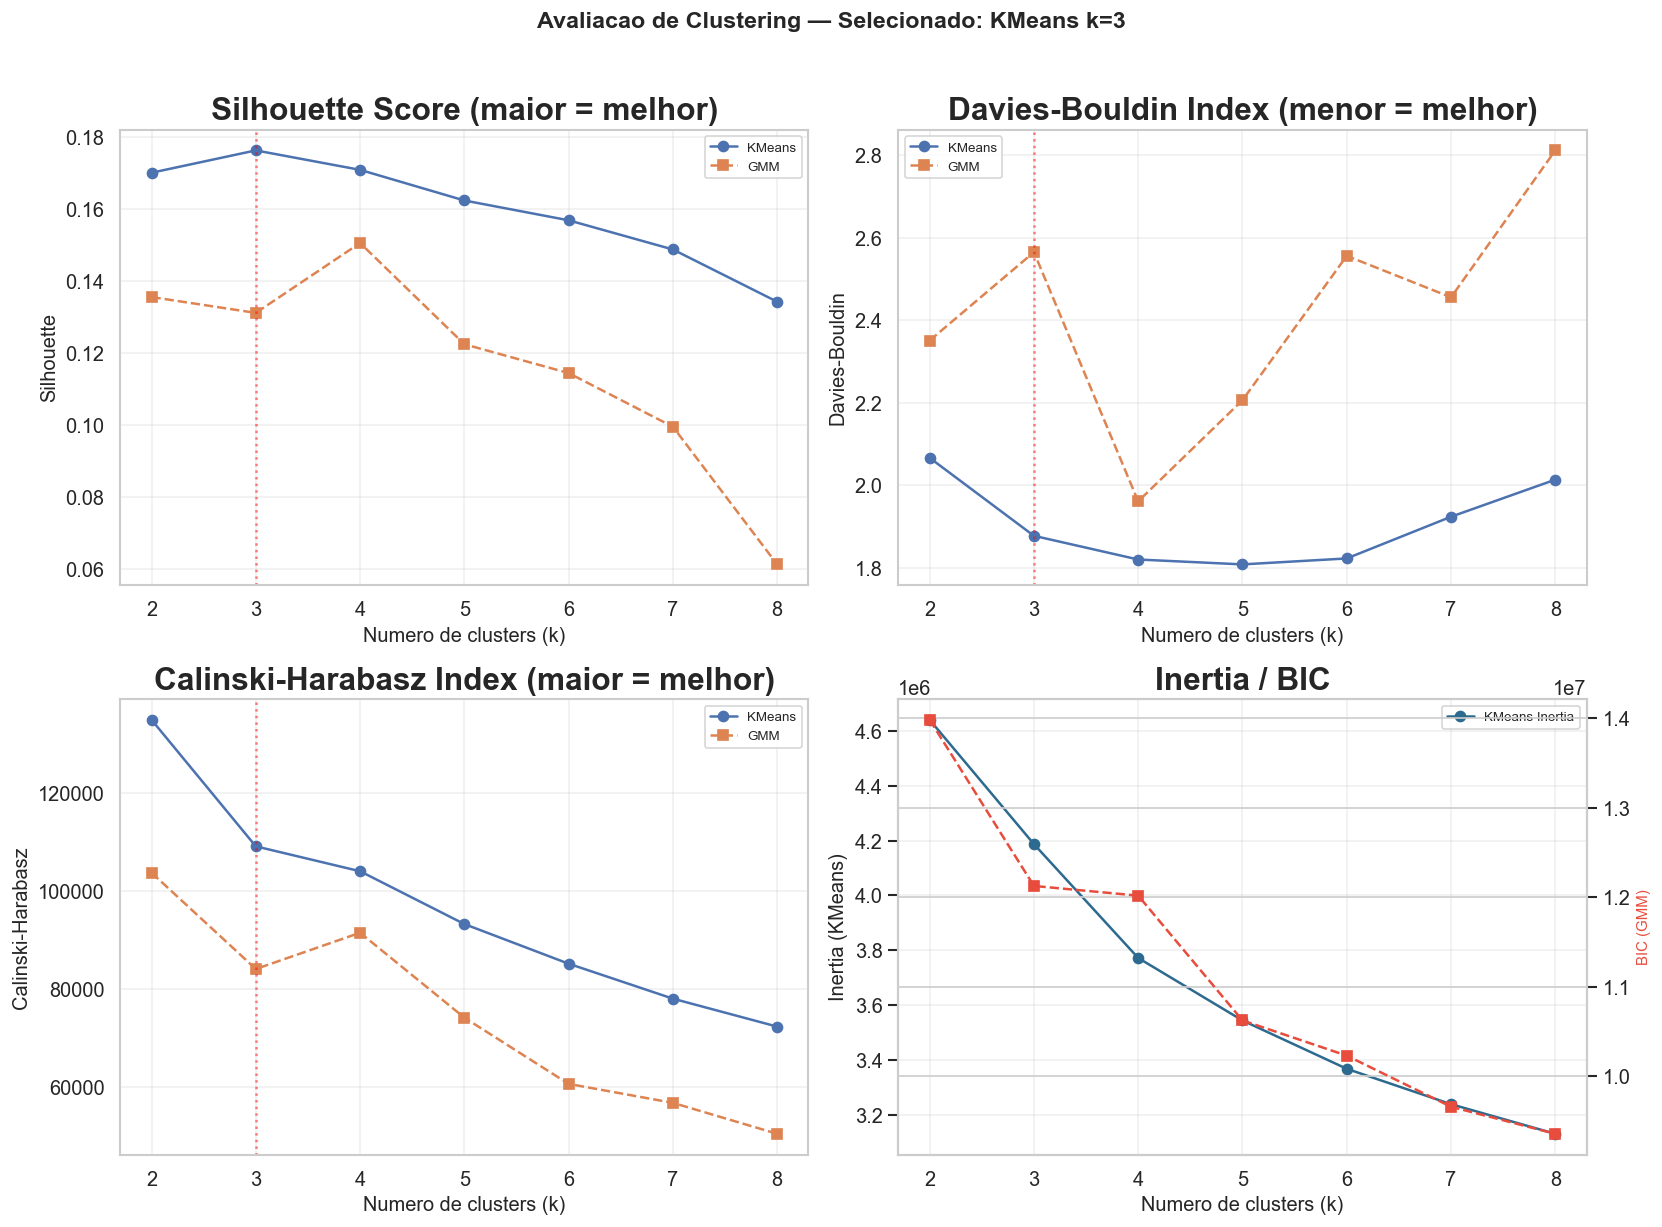

In [42]:
# --- 6.1 Métricas por k (Silhouette, DB, CH, Inertia/BIC) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plotar KMeans e GMM com marcadores distintos
for algo, marker, ls in [("KMeans", "o", "-"), ("GMM", "s", "--")]:
    subset = [r for r in resultados if r["algoritmo"] == algo]
    ks = [r["n_clusters"] for r in subset]
    axes[0, 0].plot(ks, [r["silhouette"] for r in subset], marker=marker, ls=ls, label=algo)
    axes[0, 1].plot(ks, [r["davies_bouldin"] for r in subset], marker=marker, ls=ls, label=algo)
    axes[1, 0].plot(ks, [r["calinski_harabasz"] for r in subset], marker=marker, ls=ls, label=algo)

# Plotar DBSCAN como ponto isolado (se teve métricas válidas)
dbscan_plot = [r for r in resultados if r["algoritmo"] == "DBSCAN" and r["silhouette"] is not None]
if dbscan_plot:
    db_r = dbscan_plot[0]
    axes[0, 0].scatter([db_r["n_clusters"]], [db_r["silhouette"]], marker="D", s=100, c="green",
                        zorder=5, label=f"DBSCAN (k={db_r['n_clusters']})", edgecolors="black")
    axes[0, 1].scatter([db_r["n_clusters"]], [db_r["davies_bouldin"]], marker="D", s=100, c="green",
                        zorder=5, label=f"DBSCAN (k={db_r['n_clusters']})", edgecolors="black")
    axes[1, 0].scatter([db_r["n_clusters"]], [db_r["calinski_harabasz"]], marker="D", s=100, c="green",
                        zorder=5, label=f"DBSCAN (k={db_r['n_clusters']})", edgecolors="black")

# Inertia (KMeans) e BIC (GMM) no mesmo subplot com eixo duplo
km_sub = [r for r in resultados if r["algoritmo"] == "KMeans"]
axes[1, 1].plot([r["n_clusters"] for r in km_sub], [r["inertia"] for r in km_sub],
                "o-", color="#2d6a8f", label="KMeans Inertia")
gmm_sub = [r for r in resultados if r["algoritmo"] == "GMM"]
ax_bic = axes[1, 1].twinx()
ax_bic.plot([r["n_clusters"] for r in gmm_sub], [r["bic"] for r in gmm_sub],
            "s--", color="#e74c3c", label="GMM BIC")
ax_bic.set_ylabel("BIC (GMM)", fontsize=9, color="#e74c3c")

# Formatação dos subplots
titles = ["Silhouette Score (maior = melhor)", "Davies-Bouldin Index (menor = melhor)",
          "Calinski-Harabasz Index (maior = melhor)", "Inertia / BIC"]
ylabels = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz", "Inertia (KMeans)"]
for i, ax in enumerate(axes.flatten()):
    ax.set_title(titles[i], fontweight="bold")
    ax.set_ylabel(ylabels[i])
    ax.set_xlabel("Numero de clusters (k)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Linha vertical no k selecionado
for ax in [axes[0, 0], axes[0, 1], axes[1, 0]]:
    ax.axvline(best_k, color="red", linestyle=":", alpha=0.5)

fig.suptitle(f"Avaliacao de Clustering — Selecionado: {best_algo} k={best_k}",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v2_01_metricas_clustering.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "metricas_clustering", fig, "S1c_v2_01_metricas_clustering.png")
plt.show()

### 6.2 - Scatter PCA 2D

**Objetivo:** Projetar os dados em 2 componentes principais (GPU) e visualizar a separação dos clusters no espaço reduzido.

**Parâmetros:**
- `n_sample = 50000`: amostragem para legibilidade do scatter plot (evitar sobreposição excessiva)
- `alpha = 0.3`: transparência dos pontos para revelar densidade


PCA na GPU...
  Variancia PC1+PC2: 39.4%
[db_utils] Imagem 'pca_clusters' salva para etapa s1c


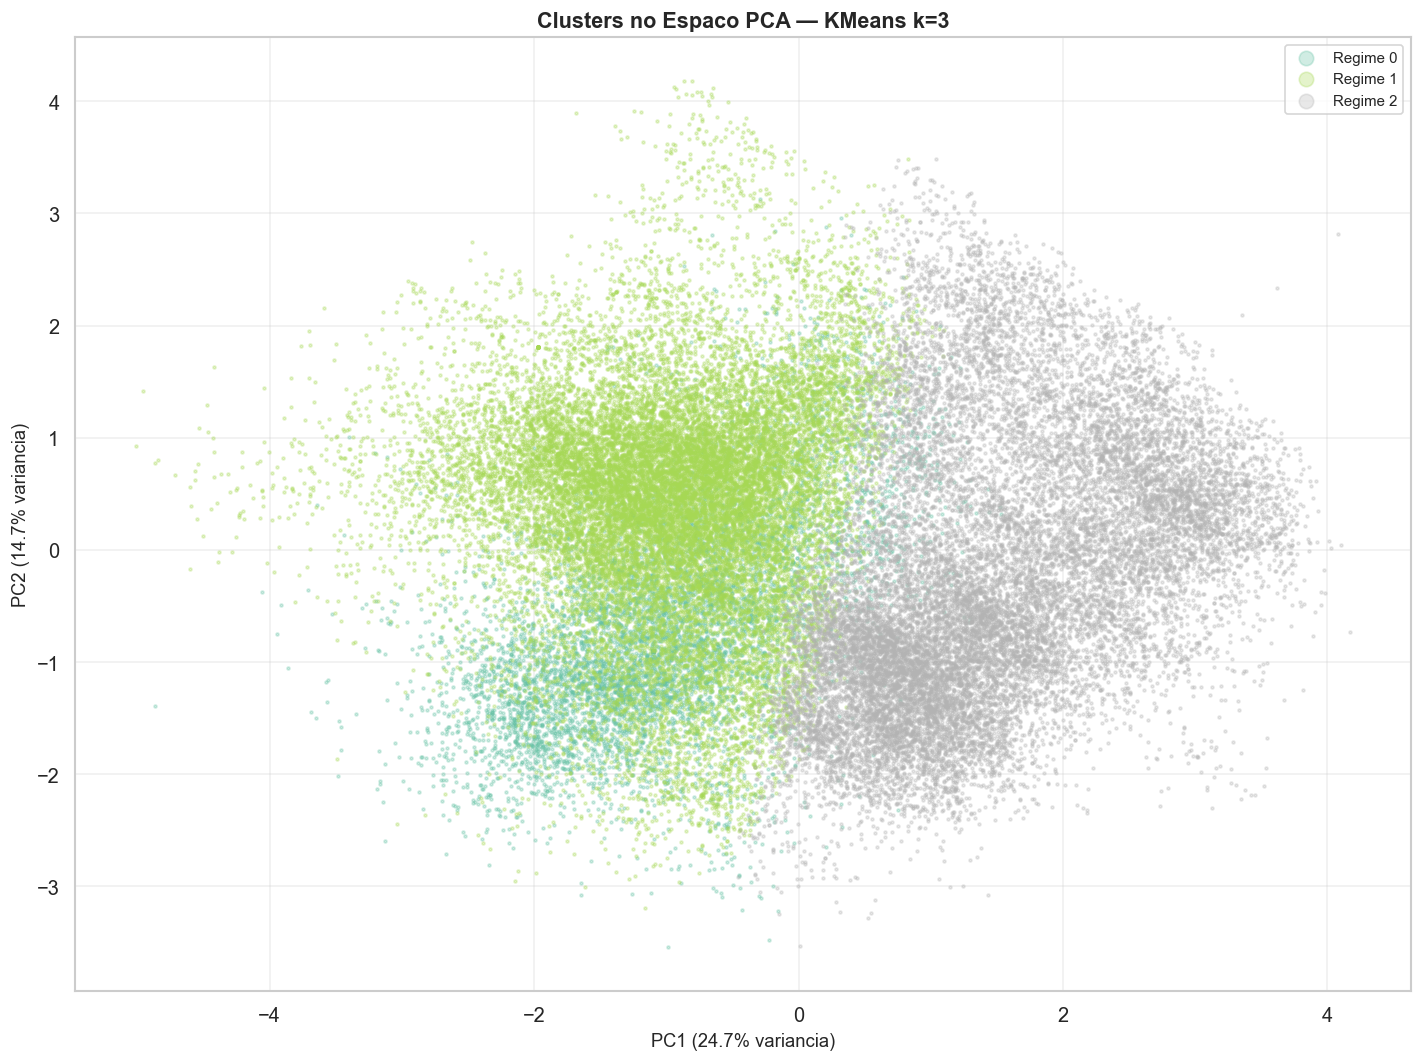

In [43]:
# --- 6.2 Scatter PCA 2D (projeção na GPU) ---
print("\nPCA na GPU...")
X_pca, var_explained = pca_gpu(X_tensor, n_components=2)
print(f"  Variancia PC1+PC2: {sum(var_explained[:2])*100:.1f}%")

# Amostragem para legibilidade do scatter
n_sample = min(50000, len(X_pca))
idx_sample = np.random.RandomState(42).choice(len(X_pca), n_sample, replace=False)

fig, ax = plt.subplots(figsize=(12, 9))
for rid in range(best_k):
    mask = best_labels[idx_sample] == rid
    ax.scatter(X_pca[idx_sample[mask], 0], X_pca[idx_sample[mask], 1],
               c=[colors_regime[rid]], s=3, alpha=0.3, label=f"Regime {rid}")
ax.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% variancia)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variancia)", fontsize=11)
ax.set_title(f"Clusters no Espaco PCA — {best_algo} k={best_k}", fontsize=13, fontweight="bold")
if SHOW_LEGEND: ax.legend(fontsize=9, markerscale=5)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v2_02_pca_clusters.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "pca_clusters", fig, "S1c_v2_02_pca_clusters.png")
plt.show()

### 6.3 - Distribuição de TPH por Regime

**Objetivo:** Comparar a distribuição da variável de produção (TPH — alimentação da balança) entre regimes, usando histograma de densidade e boxplot lado a lado.

[db_utils] Imagem 'tph_por_regime' salva para etapa s1c


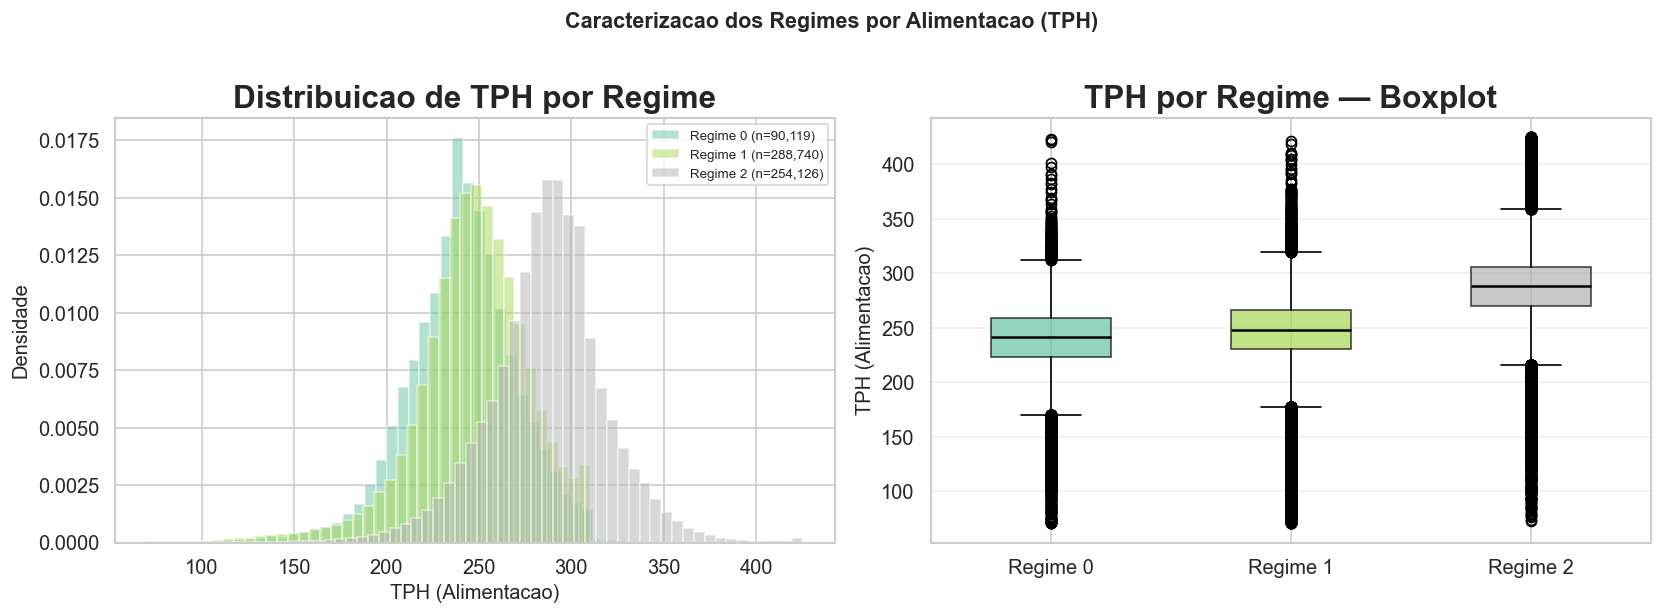

In [44]:
# --- 6.3 Distribuição de TPH por regime (histograma + boxplot) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de densidade
ax = axes[0]
for rid in range(best_k):
    mask = df_clean_regime["regime"] == rid
    ax.hist(df_clean_regime.loc[mask, col_tph], bins=60, alpha=0.5,
            color=colors_regime[rid], label=f"Regime {rid} (n={mask.sum():,})", density=True)
ax.set_xlabel("TPH (Alimentacao)")
ax.set_ylabel("Densidade")
ax.set_title("Distribuicao de TPH por Regime", fontweight="bold")
if SHOW_LEGEND: ax.legend(fontsize=8)

# Boxplot comparativo
ax = axes[1]
data_box = [df_clean_regime.loc[df_clean_regime["regime"] == r, col_tph].values for r in range(best_k)]
bp = ax.boxplot(data_box, labels=[f"Regime {r}" for r in range(best_k)], patch_artist=True, widths=0.5)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors_regime[i]); patch.set_alpha(0.7)
for m in bp["medians"]:
    m.set_color("black"); m.set_linewidth(1.5)
ax.set_ylabel("TPH (Alimentacao)")
ax.set_title("TPH por Regime — Boxplot", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Caracterizacao dos Regimes por Alimentacao (TPH)", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v2_03_tph_por_regime.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "tph_por_regime", fig, "S1c_v2_03_tph_por_regime.png")
plt.show()

### 6.4 - Radar Chart dos Centroides

**Objetivo:** Visualizar o perfil multivariado de cada regime usando as 10 variáveis mais discriminantes (maior desvio padrão entre centroides normalizados).

**Justificativa:** O radar chart permite comparar rapidamente as "assinaturas" operacionais de cada regime em múltiplas variáveis simultaneamente.

[db_utils] Imagem 'radar_centroides' salva para etapa s1c


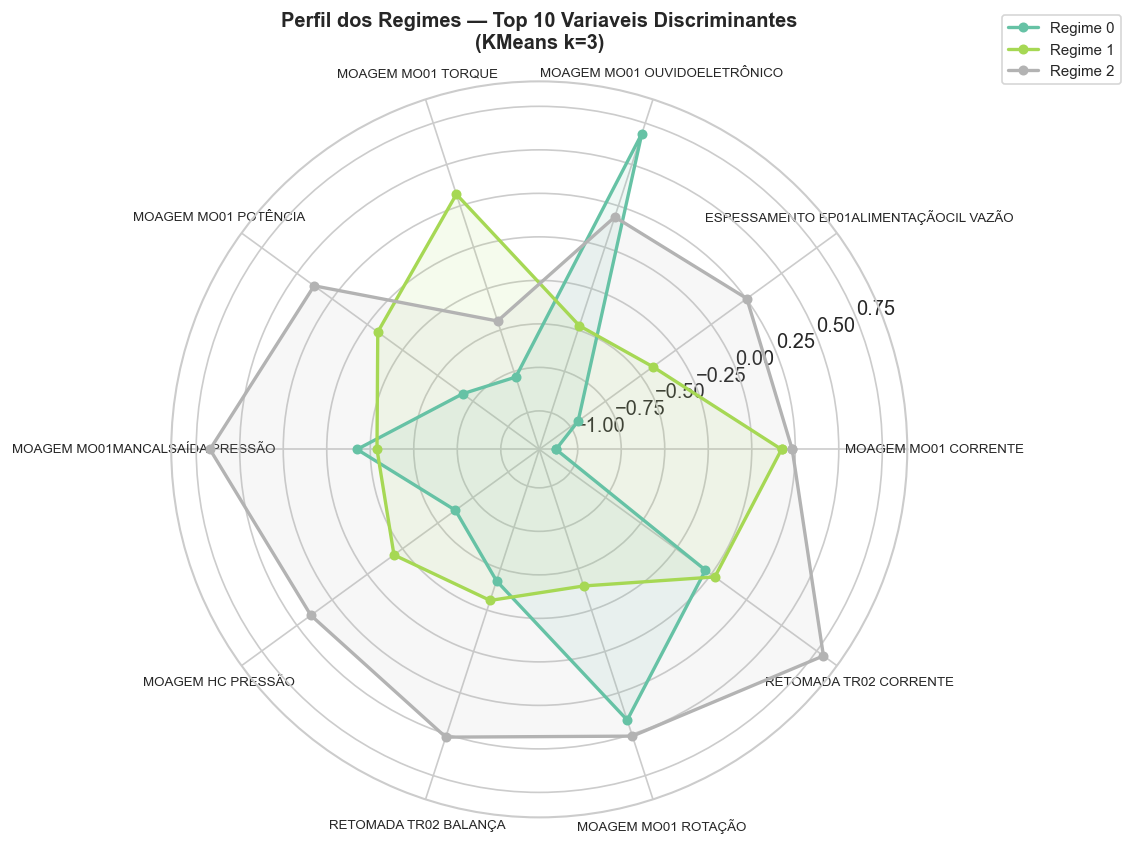

In [45]:
# --- 6.4 Radar chart dos centroides (top 10 variáveis discriminantes) ---

# Normalizar centroides para comparação justa no radar
centroides_norm = pd.DataFrame(scaler.transform(centroides_orig.values),
                                columns=COLS_CLUSTER, index=centroides_orig.index)

# Selecionar as 10 variáveis com maior discriminação entre regimes
var_disc = centroides_norm.std(axis=0).sort_values(ascending=False)
top_vars = var_disc.head(10).index.tolist()
labels_radar = [NOMES_CURTOS[v] for v in top_vars]

# Ângulos do radar (fechando o polígono)
angles = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for rid in range(best_k):
    vals = centroides_norm.loc[rid, top_vars].values.tolist() + [centroides_norm.loc[rid, top_vars].values[0]]
    ax.plot(angles, vals, "o-", color=colors_regime[rid], linewidth=2, markersize=5, label=f"Regime {rid}")
    ax.fill(angles, vals, color=colors_regime[rid], alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=8)
ax.set_title(f"Perfil dos Regimes — Top 10 Variaveis Discriminantes\n({best_algo} k={best_k})",
             fontsize=12, fontweight="bold", pad=20)
if SHOW_LEGEND: ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v2_04_radar_centroides.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "radar_centroides", fig, "S1c_v2_04_radar_centroides.png")
plt.show()

### 6.5 - Série Temporal dos Regimes

**Objetivo:** Visualizar a alternância de regimes ao longo do tempo, reamostrado por hora (moda do regime em cada hora).

**Justificativa:** Permite verificar se os regimes correspondem a padrões temporais reais (turnos, paradas, variações sazonais) e se há estabilidade ou oscilação excessiva.

[db_utils] Imagem 'serie_temporal_regimes' salva para etapa s1c


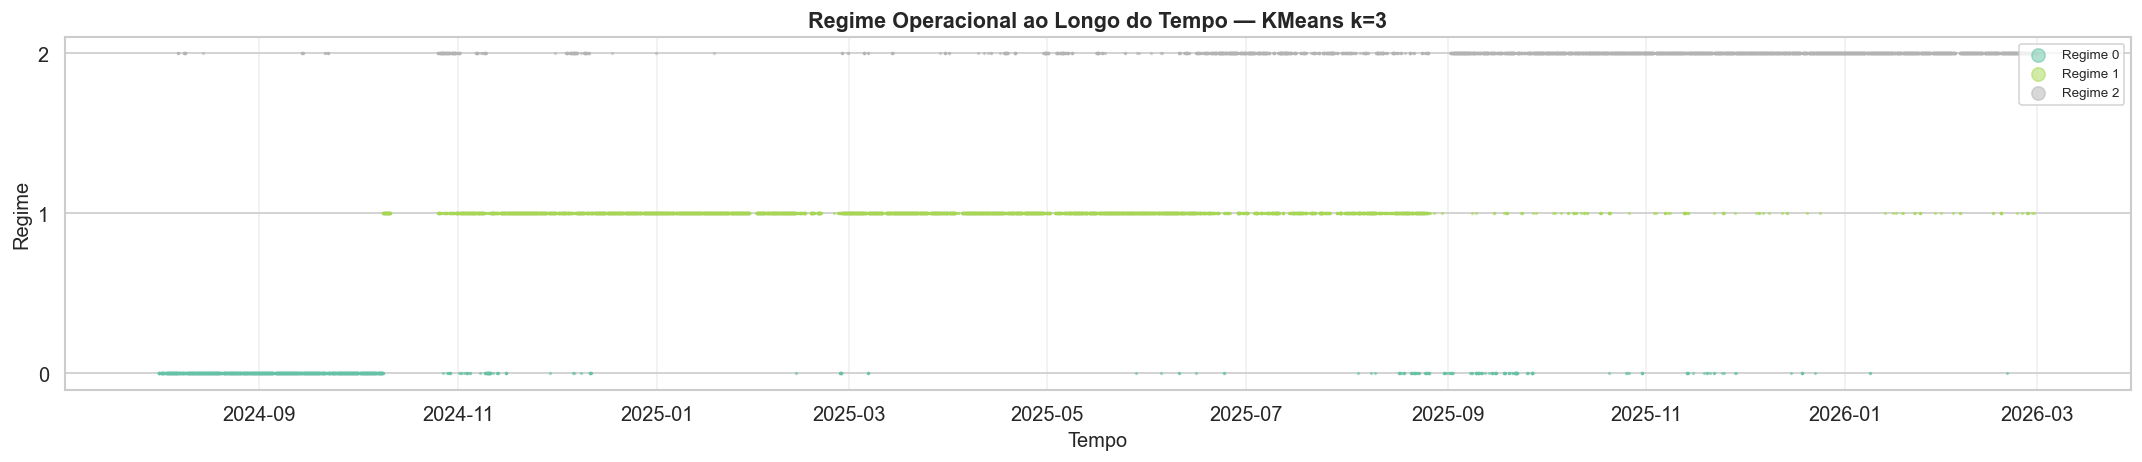

In [46]:
# --- 6.5 Série temporal dos regimes (reamostrado por hora) ---
df_ts = df_clean_regime[["regime"]].copy()

# Moda do regime em cada janela de 1 hora
regime_h = df_ts["regime"].resample("1h").agg(lambda x: x.mode().iloc[0] if len(x) > 0 else np.nan).dropna()

fig, ax = plt.subplots(figsize=(18, 4))
for rid in range(best_k):
    mask = regime_h == rid
    ax.scatter(regime_h.index[mask], regime_h[mask], c=[colors_regime[rid]], s=1, alpha=0.5, label=f"Regime {rid}")
ax.set_xlabel("Tempo"); ax.set_ylabel("Regime"); ax.set_yticks(range(best_k))
ax.set_title(f"Regime Operacional ao Longo do Tempo — {best_algo} k={best_k}", fontsize=13, fontweight="bold")
if SHOW_LEGEND: ax.legend(fontsize=8, markerscale=8, loc="upper right")
ax.grid(True, alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v2_05_serie_temporal_regimes.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "serie_temporal_regimes", fig, "S1c_v2_05_serie_temporal_regimes.png")
plt.show()

### 6.6 - Heatmap dos Centroides

**Objetivo:** Mostrar os centroides normalizados de todos os regimes em todas as variáveis de processo, permitindo identificar quais variáveis diferenciam cada regime.

**Justificativa:** O heatmap complementa o radar chart ao mostrar TODAS as variáveis (não só o top 10), facilitando a identificação de padrões sutis.

[db_utils] Imagem 'heatmap_centroides' salva para etapa s1c


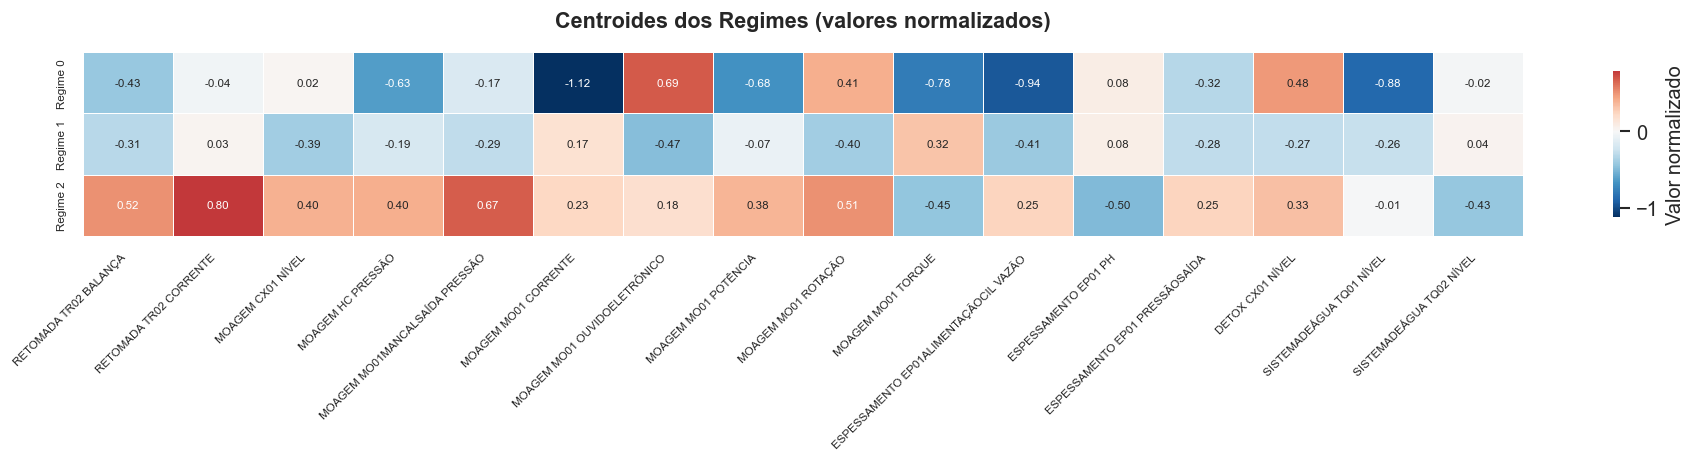

In [47]:
# --- 6.6 Heatmap dos centroides normalizados (todas as variáveis) ---
fig, ax = plt.subplots(figsize=(16, max(4, best_k * 1.2)))
labels_heat = [NOMES_CURTOS[c] for c in COLS_CLUSTER]
sns.heatmap(centroides_norm[COLS_CLUSTER].values, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.3, xticklabels=labels_heat,
            yticklabels=[f"Regime {r}" for r in range(best_k)],
            annot_kws={"size": 7}, ax=ax, cbar_kws={"shrink": 0.8, "label": "Valor normalizado"})
ax.set_title("Centroides dos Regimes (valores normalizados)", fontsize=13, fontweight="bold", pad=15)
ax.tick_params(labelsize=7)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_v2_06_heatmap_centroides.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "heatmap_centroides", fig, "S1c_v2_06_heatmap_centroides.png")
plt.show()

## 7 - Salvamento dos Resultados

**Objetivo:** Persistir todos os resultados do clustering para consumo pelo dashboard e
rastreabilidade entre versões do pipeline.

**Armazenamento local (parquet/CSV):**
- `dados_com_clusters_v2.parquet`: dataset completo com coluna `regime` adicionada
- `metricas_clustering_v2.csv`: métricas de validação de todos os algoritmos/k
- `regimes_v2.csv`: estatísticas descritivas de cada regime

**Armazenamento no banco (PostgreSQL):**
- `s1c_v2_metricas_clustering`: métricas para o dashboard
- `s1c_v2_regimes`: caracterização dos regimes
- `s1c_v2_regime_centroides`: centroides em formato longo (regime x variável x valor)

**Importante:** Os dados NÃO são salvos na tabela `dados_com_clusters` (reservada para a
versão final v3). Cada versão usa stage próprio (`s1c_v2`) para evitar sobrescrever resultados.

In [48]:
# ==============================================================================
# Salvar resultados: parquet local + métricas/imagens no banco
# ==============================================================================
print("\nSalvando resultados...")

# Preparar métricas de validação (todos os algoritmos/k avaliados)
df_metricas = pd.DataFrame([{
    "algoritmo": r["algoritmo"], "n_clusters": r["n_clusters"],
    "silhouette": r["silhouette"], "davies_bouldin": r["davies_bouldin"],
    "calinski_harabasz": r["calinski_harabasz"], "inertia": r["inertia"],
    "bic": r["bic"], "selecionado": r["selecionado"],
} for r in resultados])

# Salvar métricas em CSV para comparação entre versões
df_metricas.to_csv(DATA_PROC / "metricas_clustering_v2.csv", index=False)
df_regimes.to_csv(DATA_PROC / "regimes_v2.csv", index=False)
print(f"  Métricas CSV: {DATA_PROC / 'metricas_clustering_v2.csv'}")
print(f"  Regimes CSV: {DATA_PROC / 'regimes_v2.csv'}")

# Salvar log de preprocessing
df_prep_log = pd.DataFrame(preprocessing_log)
df_prep_log.to_csv(DATA_PROC / "preprocessing_log_v2.csv", index=False)
print(f"  Preprocessing log: {DATA_PROC / 'preprocessing_log_v2.csv'}")

# ── Salvar log completo de TODOS os testes (KMeans + DBSCAN + GMM) ──
todos_testes = []
for r in resultados:
    todos_testes.append({
        "algoritmo": r["algoritmo"], "n_clusters": r["n_clusters"],
        "silhouette": r["silhouette"], "davies_bouldin": r["davies_bouldin"],
        "calinski_harabasz": r["calinski_harabasz"],
        "inertia": r["inertia"], "bic": r["bic"],
        "eps": None, "min_samples": None, "pct_noise": None,
        "selecionado": r["selecionado"],
    })
for r in dbscan_results:
    todos_testes.append({
        "algoritmo": "DBSCAN", "n_clusters": r["n_clusters"],
        "silhouette": r["silhouette"], "davies_bouldin": None,
        "calinski_harabasz": None,
        "inertia": None, "bic": None,
        "eps": r["eps"], "min_samples": r["min_samples"],
        "pct_noise": r["pct_noise"],
        "selecionado": False,
    })
df_todos_testes = pd.DataFrame(todos_testes)
df_todos_testes.to_csv(DATA_PROC / "todos_testes_clustering_v2.csv", index=False)
salvar_dataframe(df_todos_testes, "s1c_v2_todos_testes", modo="replace")
print(f"  Todos os testes: {len(df_todos_testes)} registros → s1c_v2_todos_testes")

# Construir dataset completo com coluna regime (ANTES de salvar no banco)
df_output = df.reset_index()
df_output["regime"] = np.nan
# Atribuir regimes alinhando por índice (não por posição) para evitar mismatch
regime_series = df_clean_regime["regime"].rename("_regime_tmp")
df_output = df_output.merge(
    regime_series.reset_index().rename(columns={regime_series.index.name or "index": "Timestamp", "_regime_tmp": "regime_aligned"}),
    on="Timestamp", how="left"
)
df_output["regime"] = df_output["regime_aligned"].astype("Int64")
df_output = df_output.drop(columns=["regime_aligned"])

# Salvar métricas e regimes no banco com stage específico (não sobrescreve v3)
salvar_dataframe(df_metricas, "s1c_v2_metricas_clustering")
salvar_dataframe(df_regimes, "s1c_v2_regimes")
salvar_dataframe(df_centroides, "s1c_v2_regime_centroides")
# Dataset completo com regimes (rastreabilidade)
salvar_dataframe(df_output, "s1c_v2_dados_com_clusters", modo="replace")
print(f"  Banco: s1c_v2_metricas_clustering, s1c_v2_regimes, s1c_v2_regime_centroides")
print(f"  Banco: s1c_v2_dados_com_clusters ({len(df_output):,} linhas)")

# Salvar parquet versionado
df_output.to_parquet(DATA_PROC / "dados_com_clusters_v2.parquet", index=False)
print(f"  Parquet: {DATA_PROC / 'dados_com_clusters_v2.parquet'} ({len(df_output):,} linhas)")

# Liberar memória da GPU (se disponível)
del X_tensor
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("  Memória liberada")


Salvando resultados...
  Métricas CSV: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\metricas_clustering_v2.csv
  Regimes CSV: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\regimes_v2.csv
  Preprocessing log: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\preprocessing_log_v2.csv
[db_utils] 59 linhas salvas em otimizar_moagem_aura.s1c_v2_todos_testes
  Todos os testes: 59 registros → s1c_v2_todos_testes
[db_utils] 15 linhas salvas em otimizar_moagem_aura.s1c_v2_metricas_clustering
[db_utils] 3 linhas salvas em otimizar_moagem_aura.s1c_v2_regimes
[db_utils] 48 linhas salvas em otimizar_moagem_aura.s1c_v2_regime_centroides
[db_utils] s1c_v2_dados_com_clusters: 500,000 / 632,985 (79.0%)
[db_utils] s1c_v2_dados_com_clusters: 632,985 / 632,985 (100.0%)
[db_utils] 632,985 linhas salvas em otimizar_moagem_aura.s1c_v2_dados_com_clusters
  Banco: s1c_v2_metricas_clustering, s1c_v2_regimes, s1c_v2_regime_centroides
  Banco: s1c_v2_dados_com_clusters (632,985 linh

## 7.5 - Comparativo v1 vs v2

**Objetivo:** Gerar visualizações comparativas entre a versão original (v1: StandardScaler, todas as variáveis, sem preprocessing) e a versão melhorada (v2: RobustScaler, seleção de features, Hampel, quasi-constantes, colinearidade, DBSCAN sweep).

As figuras são salvas com prefixo `comp_` para exibição na aba de comparação do dashboard.


--- Gerando comparativo v1 vs v2 ---
[db_utils] 15 linhas carregadas de otimizar_moagem_aura.s1c_v1_metricas_clustering
[db_utils] 2 linhas carregadas de otimizar_moagem_aura.s1c_v1_regimes
  v1: 15 métricas, 2 regimes (banco)
[db_utils] Imagem 'comp_silhouette_v1_v2' salva para etapa s1c


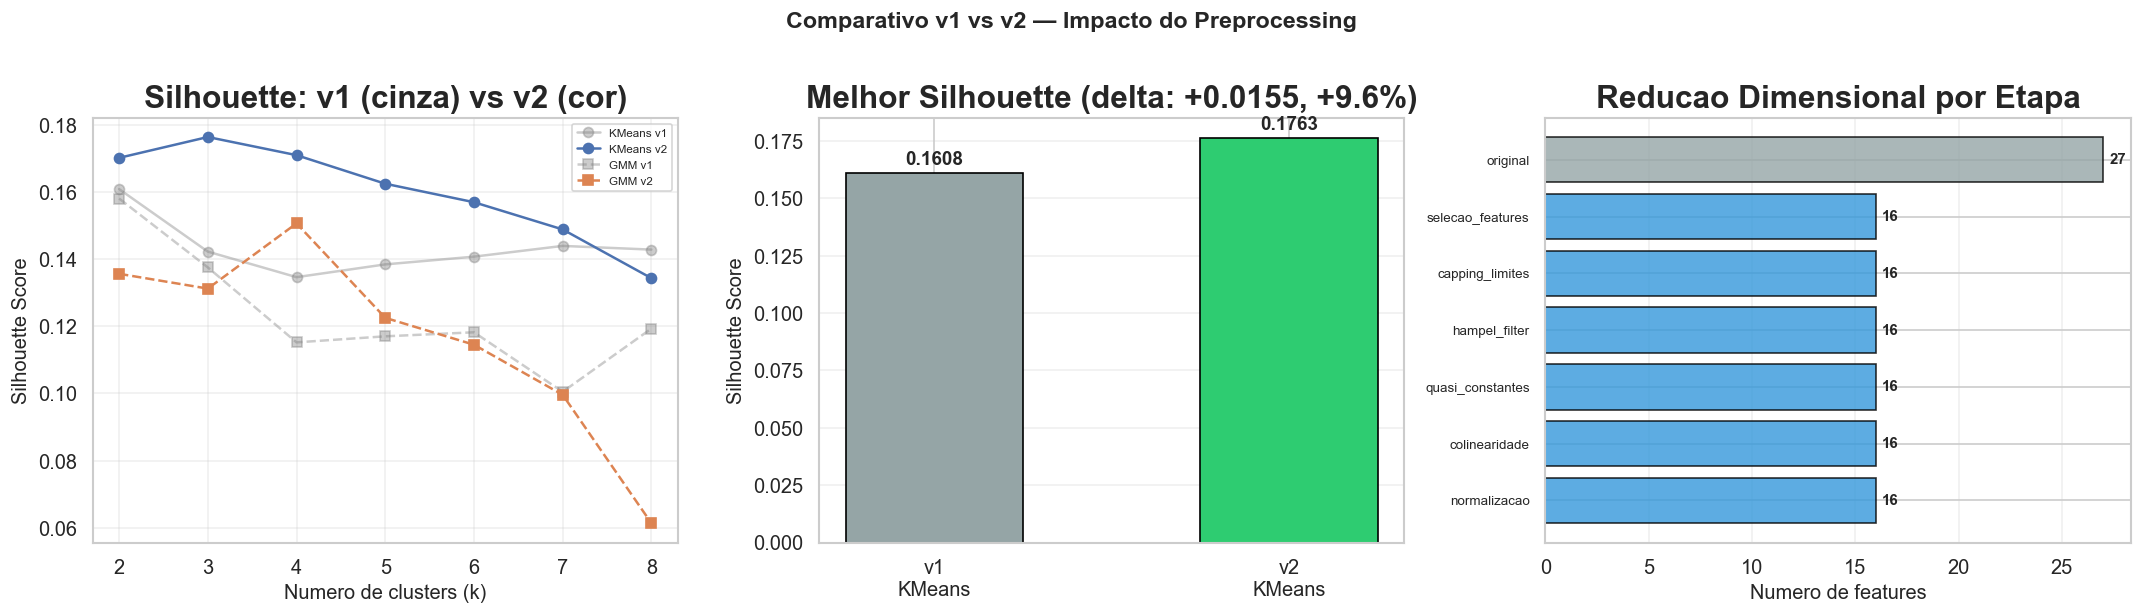

[db_utils] Imagem 'comp_regimes_v1_v2' salva para etapa s1c


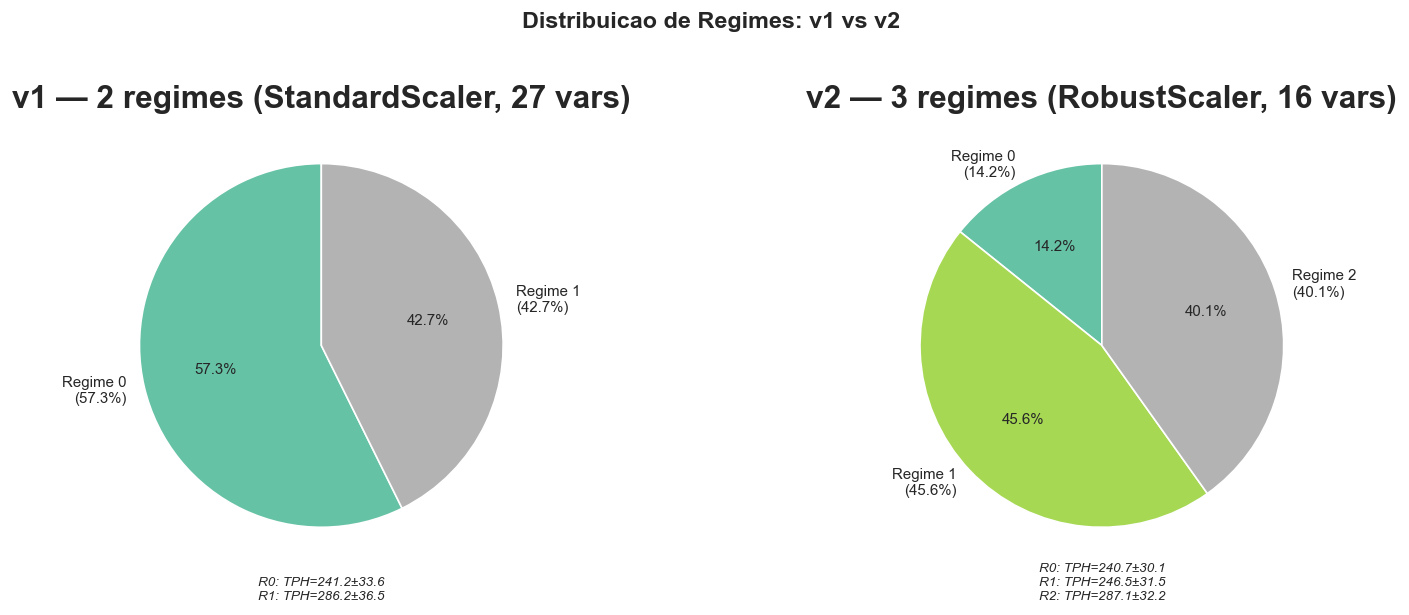

[db_utils] Imagem 'comp_tabela_resumo' salva para etapa s1c


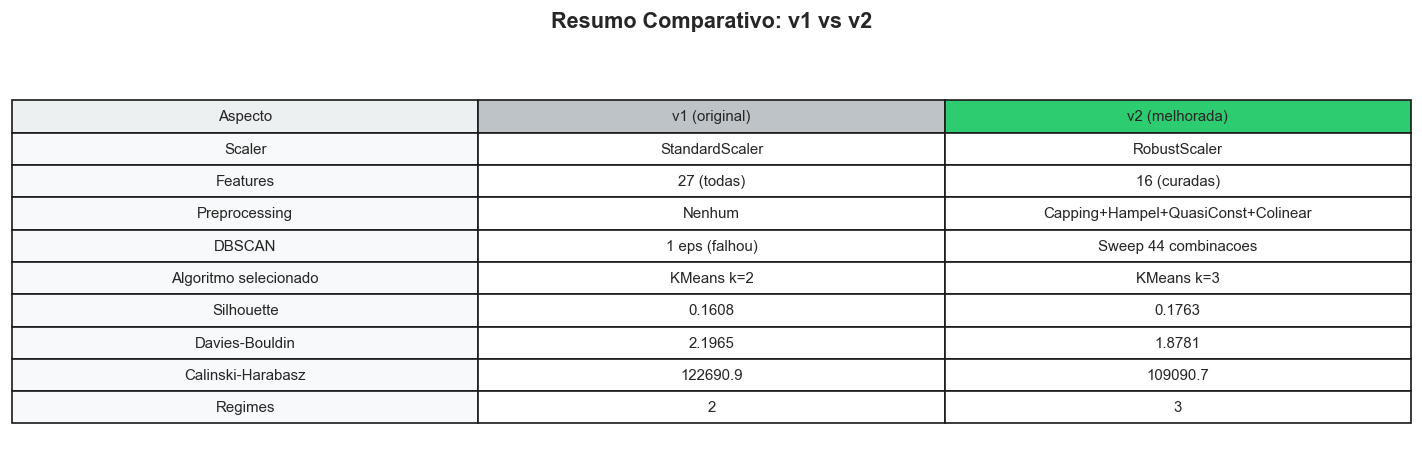

Figuras comparativas salvas!


In [49]:
# ==============================================================================
# 7.5 Comparativo v1 vs v2
# ==============================================================================
print("\n--- Gerando comparativo v1 vs v2 ---")

# Carregar dados v1 (banco com fallback para CSV)
try:
    df_metricas_v1 = carregar_dados("s1c_v1_metricas_clustering")
    df_regimes_v1 = carregar_dados("s1c_v1_regimes")
    print(f"  v1: {len(df_metricas_v1)} métricas, {len(df_regimes_v1)} regimes (banco)")
except Exception:
    try:
        df_metricas_v1 = pd.read_csv(DATA_PROC / "metricas_clustering_v1.csv")
        df_regimes_v1 = pd.read_csv(DATA_PROC / "regimes_v1.csv")
        print(f"  v1: {len(df_metricas_v1)} métricas, {len(df_regimes_v1)} regimes (CSV local)")
    except FileNotFoundError:
        print("  v1: dados não encontrados — execute c_clustering_regimes_v1.ipynb primeiro")
        print("  Pulando comparativo v1 vs v2.")
        df_metricas_v1 = pd.DataFrame()
        df_regimes_v1 = pd.DataFrame()

if len(df_metricas_v1) > 0:
    # --- Figura 1: Comparação de Silhouette Score (v1 vs v2) ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1a. Silhouette por algoritmo/k
    ax = axes[0]
    for algo, marker, ls in [("KMeans", "o", "-"), ("GMM", "s", "--")]:
        # v1
        v1_sub = df_metricas_v1[df_metricas_v1["algoritmo"] == algo]
        if len(v1_sub) > 0:
            ax.plot(v1_sub["n_clusters"], v1_sub["silhouette"], marker=marker, ls=ls,
                    alpha=0.4, color="gray", label=f"{algo} v1")
        # v2
        v2_sub = [r for r in resultados if r["algoritmo"] == algo]
        ks = [r["n_clusters"] for r in v2_sub]
        sils = [r["silhouette"] for r in v2_sub]
        ax.plot(ks, sils, marker=marker, ls=ls, label=f"{algo} v2")

    # DBSCAN v2 (se válido)
    dbscan_v2 = [r for r in resultados if r["algoritmo"] == "DBSCAN" and r["silhouette"] is not None]
    if dbscan_v2:
        db_r = dbscan_v2[0]
        ax.scatter([db_r["n_clusters"]], [db_r["silhouette"]], marker="D", s=100, c="green",
                   zorder=5, label=f"DBSCAN v2 (k={db_r['n_clusters']})", edgecolors="black")

    ax.set_xlabel("Numero de clusters (k)")
    ax.set_ylabel("Silhouette Score")
    ax.set_title("Silhouette: v1 (cinza) vs v2 (cor)", fontweight="bold")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # 1b. Melhor Silhouette de cada versão (barras)
    ax = axes[1]
    v1_best_sil = df_metricas_v1["silhouette"].max() if len(df_metricas_v1) > 0 else 0
    v2_best_sil = max(r["silhouette"] for r in resultados if r["silhouette"] is not None)
    v1_best_algo = df_metricas_v1.loc[df_metricas_v1["silhouette"].idxmax(), "algoritmo"] if len(df_metricas_v1) > 0 else "?"
    v2_best_algo = best_algo

    bars = ax.bar(["v1\n" + v1_best_algo, "v2\n" + v2_best_algo],
                  [v1_best_sil, v2_best_sil],
                  color=["#95a5a6", "#2ecc71"], width=0.5, edgecolor="black")
    for bar, val in zip(bars, [v1_best_sil, v2_best_sil]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom", fontweight="bold")
    delta = v2_best_sil - v1_best_sil
    pct_delta = 100 * delta / v1_best_sil if v1_best_sil > 0 else 0
    ax.set_title(f"Melhor Silhouette (delta: {delta:+.4f}, {pct_delta:+.1f}%)", fontweight="bold")
    ax.set_ylabel("Silhouette Score")
    ax.grid(True, alpha=0.3, axis="y")

    # 1c. Pipeline de preprocessing (etapas e redução dimensional)
    ax = axes[2]
    etapas = [log["etapa"].split("_", 1)[1] for log in preprocessing_log]
    cols_progression = [preprocessing_log[0]["colunas_antes"]] + [log["colunas_depois"] for log in preprocessing_log]
    etapas_labels = ["original"] + etapas
    colors_bar = ["#95a5a6"] + ["#3498db"] * len(etapas)
    ax.barh(range(len(cols_progression)), cols_progression, color=colors_bar, edgecolor="black", alpha=0.8)
    ax.set_yticks(range(len(etapas_labels)))
    ax.set_yticklabels(etapas_labels, fontsize=8)
    ax.set_xlabel("Numero de features")
    ax.set_title("Reducao Dimensional por Etapa", fontweight="bold")
    for i, v in enumerate(cols_progression):
        ax.text(v + 0.3, i, str(v), va="center", fontsize=9, fontweight="bold")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis="x")

    fig.suptitle("Comparativo v1 vs v2 — Impacto do Preprocessing", fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "S1c_v2_07_comp_silhouette_v1_v2.png", dpi=150, bbox_inches="tight")
    salvar_imagem(STAGE, "comp_silhouette_v1_v2", fig, "S1c_v2_07_comp_silhouette_v1_v2.png")
    plt.show()

    # --- Figura 2: Comparação de regimes (distribuição TPH) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # v1 regimes
    ax = axes[0]
    if len(df_regimes_v1) > 0:
        labels_v1 = [f"Regime {int(r['regime'])}\n({r['percentual']:.1f}%)" for _, r in df_regimes_v1.iterrows()]
        sizes_v1 = df_regimes_v1["percentual"].values
        colors_v1 = plt.cm.Set2(np.linspace(0, 1, len(df_regimes_v1)))
        ax.pie(sizes_v1, labels=labels_v1, colors=colors_v1, autopct="%.1f%%",
               startangle=90, textprops={"fontsize": 9})
        tph_info = "\n".join([f"R{int(r['regime'])}: TPH={r['tph_medio']:.1f}±{r['tph_std']:.1f}"
                              for _, r in df_regimes_v1.iterrows()])
        ax.text(0, -1.4, tph_info, ha="center", fontsize=8, style="italic")
    ax.set_title(f"v1 — {len(df_regimes_v1)} regimes (StandardScaler, {27} vars)", fontweight="bold")

    # v2 regimes
    ax = axes[1]
    labels_v2 = [f"Regime {int(r['regime'])}\n({r['percentual']:.1f}%)" for _, r in df_regimes.iterrows()]
    sizes_v2 = df_regimes["percentual"].values
    colors_v2 = plt.cm.Set2(np.linspace(0, 1, len(df_regimes)))
    ax.pie(sizes_v2, labels=labels_v2, colors=colors_v2, autopct="%.1f%%",
           startangle=90, textprops={"fontsize": 9})
    tph_info_v2 = "\n".join([f"R{int(r['regime'])}: TPH={r['tph_medio']:.1f}±{r['tph_std']:.1f}"
                              for _, r in df_regimes.iterrows()])
    ax.text(0, -1.4, tph_info_v2, ha="center", fontsize=8, style="italic")
    ax.set_title(f"v2 — {len(df_regimes)} regimes (RobustScaler, {len(COLS_CLUSTER)} vars)", fontweight="bold")

    fig.suptitle("Distribuicao de Regimes: v1 vs v2", fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "S1c_v2_08_comp_regimes_v1_v2.png", dpi=150, bbox_inches="tight")
    salvar_imagem(STAGE, "comp_regimes_v1_v2", fig, "S1c_v2_08_comp_regimes_v1_v2.png")
    plt.show()

    # --- Figura 3: Tabela resumo comparativa ---
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")

    # Montar dados da tabela
    v1_sel = df_metricas_v1[df_metricas_v1["selecionado"] == True]
    v1_algo = v1_sel["algoritmo"].values[0] if len(v1_sel) > 0 else "?"
    v1_k = int(v1_sel["n_clusters"].values[0]) if len(v1_sel) > 0 else 0
    v1_sil = float(v1_sel["silhouette"].values[0]) if len(v1_sel) > 0 else 0
    v1_db = float(v1_sel["davies_bouldin"].values[0]) if len(v1_sel) > 0 else 0
    v1_ch = float(v1_sel["calinski_harabasz"].values[0]) if len(v1_sel) > 0 else 0

    table_data = [
        ["Scaler", "StandardScaler", "RobustScaler"],
        ["Features", "27 (todas)", f"{len(COLS_CLUSTER)} (curadas)"],
        ["Preprocessing", "Nenhum", "Capping+Hampel+QuasiConst+Colinear"],
        ["DBSCAN", "1 eps (falhou)", f"Sweep {len(dbscan_results)} combinacoes"],
        ["Algoritmo selecionado", f"{v1_algo} k={v1_k}", f"{best_algo} k={best_k}"],
        ["Silhouette", f"{v1_sil:.4f}", f"{v2_best_sil:.4f}"],
        ["Davies-Bouldin", f"{v1_db:.4f}", f"{best['davies_bouldin']:.4f}"],
        ["Calinski-Harabasz", f"{v1_ch:.1f}", f"{best['calinski_harabasz']:.1f}"],
        ["Regimes", f"{len(df_regimes_v1)}", f"{len(df_regimes)}"],
    ]

    table = ax.table(cellText=table_data, colLabels=["Aspecto", "v1 (original)", "v2 (melhorada)"],
                     loc="center", cellLoc="center", colColours=["#ecf0f1", "#bdc3c7", "#2ecc71"])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    # Colorir células de melhoria
    for i in range(len(table_data)):
        table[i+1, 0].set_facecolor("#f8f9fa")

    fig.suptitle("Resumo Comparativo: v1 vs v2", fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "S1c_v2_09_comp_tabela_resumo.png", dpi=150, bbox_inches="tight")
    salvar_imagem(STAGE, "comp_tabela_resumo", fig, "S1c_v2_09_comp_tabela_resumo.png")
    plt.show()

    print("Figuras comparativas salvas!")
else:
    print("  Comparativo v1 vs v2 não gerado (dados v1 indisponíveis)")

## 8 - Resumo da Execução

**Objetivo:** Exibir um resumo consolidado do pipeline de clustering (v2): modelo
selecionado, métricas de validação, variância explicada pelo PCA e distribuição dos regimes
identificados. Este resumo serve como referência rápida para comparação entre versões.

In [50]:
# 8. RESUMO
elapsed = time.time() - t0
print("\n" + "=" * 60)
print("  RESUMO DO CLUSTERING (S1c)")
print("=" * 60)
print(f"  Tempo total:           {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"  Algoritmos avaliados:  KMeans, DBSCAN, GMM")
print(f"  Algoritmo selecionado: {best_algo} k={best_k}")
print(f"  Silhouette:            {best['silhouette']}")
print(f"  Davies-Bouldin:        {best['davies_bouldin']}")
print(f"  Calinski-Harabasz:     {best['calinski_harabasz']}")
print(f"  Variancia PCA (2D):    {sum(var_explained[:2])*100:.1f}%")
print(f"  Regimes:")
for _, row in df_regimes.iterrows():
    print(f"    Regime {row['regime']}: {row['n_samples']:>8,} ({row['percentual']:5.1f}%)  "
          f"TPH={row['tph_medio']:.1f} +/- {row['tph_std']:.1f}")
print(f"  Salvos: metricas={len(df_metricas)}, regimes={len(df_regimes)}, "
      f"centroides={len(df_centroides)}, dados={len(df_output):,}, figuras=6")
print("=" * 60)


  RESUMO DO CLUSTERING (S1c)
  Tempo total:           4126s (68.8 min)
  Algoritmos avaliados:  KMeans, DBSCAN, GMM
  Algoritmo selecionado: KMeans k=3
  Silhouette:            0.1763
  Davies-Bouldin:        1.8781
  Calinski-Harabasz:     109090.7
  Variancia PCA (2D):    39.4%
  Regimes:
    Regime 0.0: 90,119.0 ( 14.2%)  TPH=240.7 +/- 30.1
    Regime 1.0: 288,740.0 ( 45.6%)  TPH=246.5 +/- 31.5
    Regime 2.0: 254,126.0 ( 40.1%)  TPH=287.1 +/- 32.2
  Salvos: metricas=15, regimes=3, centroides=48, dados=632,985, figuras=6


## 9 - Exportação HTML

**Objetivo:** Exportar o notebook completo para HTML (sem código, apenas outputs) para
documentação e compartilhamento dos resultados com a equipe.

In [51]:
# ==============================================================================
# Exportar notebook para HTML (com todos os outputs, sem código)
# ==============================================================================
from pathlib import Path
from IPython.display import display, Javascript
import time

# Salvar checkpoint do notebook antes de exportar
display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)

from nbconvert import HTMLExporter
import nbformat

_nb_path = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\notebooks\01_sprint1\clusters\c_clustering_regimes_v2.ipynb")
_html_dir = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\html")
_html_dir.mkdir(parents=True, exist_ok=True)

# Ler o notebook e converter para HTML (excluindo células de código)
with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "CLUSTER_c_clustering_regimes_v2.html"
_out_path.write_text(_html_body, encoding="utf-8")
print(f"HTML exportado: {_out_path}")

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\CLUSTER_c_clustering_regimes_v2.html
